# 채용 공고 트렌드 · ETL·EDA 통합 제출본

채용 웹 원천을 수집·정규화·통합하고 BE·DA·DE의 공고 구성과 기술 키워드를 분석한다.
이 파일은 ETL과 EDA의 코드를 순서대로 실행하는 단일 제출본이다.
[ETL 분리본](job_platform_etl.ipynb)과 [EDA 분리본](job_platform_eda.ipynb)은 별도로 유지한다.

평가자는 아래 링크로 구현·출력·해석을 함께 확인할 수 있다.
세부 채점 기준과 개선 계획은 [평가표](docs/NOTION-RUBRIC.md)에 있다.

| 번호 | 평가 항목 | 통합본의 확인 위치 |
|---|---|---|
| 1 | 동시 수집 | [ETL 2: 실행 코드·비교·Gantt](#etl-2) |
| 2 | 자동 재시도 | [ETL 2: 백오프·실패 응답 시험](#etl-2) |
| 3 | 데이터 적합성 | [ETL 1: 분할 요청·고유키·수집 범위](#etl-1) |
| 4 | 원본·정제 분리 | [ETL 3: 테이블과 원본 계보](#etl-3) |
| 5 | 중복 없는 재실행 | [ETL 4: 두 번 적재 전후 행 수](#etl-4) |
| 6 | 목적 있는 SQL | [EDA 2: 목적·윈도우 SQL·결과](#eda-2) |
| 7 | 실제 자료 시각화 | [EDA 3: 기업·조건](#eda-3), [EDA 5: 기술·역량](#eda-5) |
| 8 | 결측·분포 해석 | [EDA 1: 결측](#eda-1), [EDA 7: 분포·이상치](#eda-7) |
| 9 | 코드·실행 결과 보존 | [전체 실행 요약](#integrated-results) |
| 10 | 주제에 맞춘 구현 | [ETL 5: 중복 통합](#etl-5), [EDA 5: 키워드 분석](#eda-5) |

**실행 안내:** 저장된 출력으로 결과를 읽을 수 있다. 재실행은 프로젝트 루트에서
`python scripts/build_integrated_notebook.py`를 사용한다. `.env`의 DB 연결과 기존 Airflow 환경이 필요하다.
저장 원본을 재처리하며 새 웹 수집을 요청하지 않는다. 동시성 시간 비교는 고정 응답 시험이고,
실제 웹의 처리 속도를 의미하지 않는다. 수집 범위와 자료 기준은 각 파트의 출력에 표시한다.

<a id="etl"></a>

## A. ETL

2026-10-02 · 백엔드(BE), 데이터 분석·사이언스(DA), 데이터 엔지니어(DE)

**목적:** 서로 다른 채용 목록을 수집하고 원본·정제·관측을 분리하여, 같은 입력으로 다시 실행할 수 있는 분석 데이터를 만든다. 사용자 선택에 따라 API 키 없이 사람인·잡코리아·인크루트·링커리어 웹 원천을 사용한다.

`웹 목록 → 원본 보존 → 파싱·정규화 → 플랫폼 공고·시간별 관측 → 중복 통합 → 품질 점검`

이 노트북은 저장 원본의 파싱·멱등 시험과 실행 근거를 재검증한다. 새 웹 수집·배포·컨테이너 기동은 운영 DAG에서 수행한다. 분석 SQL, 분포와 차트, 기술 키워드 해석은 [EDA 노트북](#eda)에 있다.

In [1]:
from pathlib import Path
import hashlib, inspect, json, os, subprocess, sys
import importlib.metadata as metadata

ROOT = Path.cwd()
assert (ROOT / 'src/jobtrend/schema.sql').is_file(), '프로젝트 폴더에서 실행하세요.'
for folder in ('src', 'scripts', 'tests'):
    sys.path.insert(0, str(ROOT / folder))
from dotenv import load_dotenv
load_dotenv(ROOT / '.env')
from IPython.display import display, Markdown
import pandas as pd
from jobtrend import CODE_VERSION, collect, config, store, transform
from jobtrend.sources import REGISTRY
pd.set_option('display.max_colwidth', 85)

def query(sql, params=None):
    with store.connect() as conn:
        cursor = conn.execute(sql, params)
        return pd.DataFrame(cursor.fetchall(), columns=[c.name for c in cursor.description])

def sql_evidence(sql, params=None):
    display(Markdown('```sql\n' + sql.strip() + '\n```'))
    frame = query(sql, params)
    display(frame)
    return frame

display(pd.DataFrame([{'패키지': name, '버전': metadata.version(name)} for name in
    ('requests', 'psycopg', 'beautifulsoup4', 'pandas', 'matplotlib', 'apache-airflow')]))
display(query("SELECT current_database() AS database, current_setting('TimeZone') AS timezone"))
latest = query('SELECT run_key, slot_ts FROM v_run_scope ORDER BY slot_ts DESC LIMIT 1')
assert not latest.empty, '저장된 scheduled 실행이 필요합니다.'
RUN_KEY = latest.iloc[0].run_key
ASOF = str(latest.iloc[0].slot_ts)
print('관측 마지막 슬롯:', ASOF, '· source code_version:', CODE_VERSION)

/opt/anaconda3/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (7.0.0)/charset_normalizer (3.4.3) doesn't match a supported version!
  warnings.warn(


,패키지,버전
0,requests,2.32.5
1,psycopg,3.3.4
2,beautifulsoup4,4.12.3
3,pandas,2.3.2
4,matplotlib,3.10.6
5,apache-airflow,3.1.0


,database,timezone
0,job_platform_db,Asia/Seoul


관측 마지막 슬롯: 2026-10-02 16:20:00+09:00 · source code_version: 25c37fd3771c


<a id="etl-1"></a>

### ETL 1. 원천·분할 요청·수집 범위

원천별 직무 코드 또는 혼합 IT 목록을 페이지로 나눈다. 공고의 자연키는 `(platform, posting_id)`이고, 목록 원본의 고유키는 `(run_key, platform, query_key, page_no)`다. 시간별 관측은 `(run_key, platform, job_group, posting_id)`로 별도 보존한다.

호스트마다 요청 시작 간격 2초·동시 요청 1개를 적용한다. 기준선과 매 정각은 전수, 나머지는 최신 목록부터 신규 ID를 확인한다. 403은 중단·냉각하고 Retry-After를 따른다. 상세는 신규 공고에 한해 원천별 실행당 20개까지 필요한 필드만 저장한다. 담당자 연락처·상세 본문 원문은 보존하지 않는다.

다음 스모크는 운영에서 실제 받은 HTTP 200 원본을 재파싱한다. 혼합 목록의 세 직무 외 공고와 직무 코드의 넓은 범위를 분석 누락과 구분해야 한다. 마지막 페이지까지 받은 전수 스캔도 목록 이동에 따른 잔여 누락 가능성은 남는다.

In [2]:
sources = []
for platform, adapter in REGISTRY.items():
    for q in adapter.queries():
        sources.append({'원천': platform, '호스트': adapter.host, '질의': q.query_key,
                        '직무': q.job_group, '페이지 크기': adapter.page_size,
                        '호스트 간격(초)': adapter.min_interval_s})
display(pd.DataFrame(sources))
display(query('SELECT platform, robots_status, robots_allowed, checked_at, reason '
              'FROM source_state ORDER BY platform'))

with store.connect() as conn:
    raws = conn.execute("SELECT DISTINCT ON (platform,query_key) platform,query_key,http_status,"
        "n_items,reported_total,body,fetched_at FROM raw_listing_page "
        "WHERE outcome='ok' AND page_no=1 ORDER BY platform,query_key,fetched_at").fetchall()
smoke = []
for platform, qk, status, n, total, body, fetched_at in raws:
    q = next(q for q in REGISTRY[platform].queries() if q.query_key == qk)
    items = REGISTRY[platform].parse_items(body, q)
    filled = sum(all(x.get(key) for key in ('posting_id','company_name','title','url')) for x in items)
    assert status == 200 and items and filled == len(items)
    smoke.append({'원천': platform, '질의': qk, 'HTTP': status, '원본 목록 행': n,
                  '재파싱 행': len(items), '필수 값 채움률': filled / len(items),
                  '표시 총건수': total, '수집 시각': fetched_at})
smoke = pd.DataFrame(smoke)
assert set(smoke['원천']) == set(REGISTRY)
display(smoke)
display(query('SELECT platform,query_key,scan_kind,status,is_complete,pages_ok,pages_failed,'
              'pages_needed,items_parsed,items_unique,reported_total '
              'FROM v_listing_scope WHERE run_key=%s ORDER BY platform,query_key', (RUN_KEY,)))
display(Markdown('**해석:** `is_complete=false`인 증분 관측으로 전체 재고나 이탈을 확정하지 않는다. '
    '표시 총건수와 중복 제거 ID 수는 단위가 다를 수 있으므로 별도로 보존한다.'))

,원천,호스트,질의,직무,페이지 크기,호스트 간격(초)
0,saramin,www.saramin.co.kr,BE,BE,100,2.0
1,saramin,www.saramin.co.kr,DA,DA,100,2.0
2,saramin,www.saramin.co.kr,DE,DE,100,2.0
3,jobkorea,www.jobkorea.co.kr,BE,BE,50,2.0
4,jobkorea,www.jobkorea.co.kr,DA,DA,50,2.0
5,jobkorea,www.jobkorea.co.kr,DE,DE,50,2.0
6,incruit,job.incruit.com,BE,BE,60,2.0
7,incruit,job.incruit.com,DA,DA,60,2.0
8,incruit,job.incruit.com,DE,DE,60,2.0
9,linkareer,linkareer.com,IT,MIX,20,2.0


,platform,robots_status,robots_allowed,checked_at,reason
0,alio,NaN,False,NaT,"웹 원천만 포함: 사용자 선택, API 키 미등록"
1,incruit,200.0,True,2026-10-02 13:38:34.727560+09:00,robots 직접 확인 (reports/robots_checks.json)
2,jasoseol,403.0,False,2026-10-02 13:38:34.727560+09:00,robots 직접 확인 (reports/robots_checks.json)
3,jobkorea,200.0,True,2026-10-02 13:38:34.727560+09:00,robots 직접 확인 (reports/robots_checks.json)
4,linkareer,200.0,True,2026-10-02 13:38:34.727560+09:00,robots 직접 확인 (reports/robots_checks.json)
5,rocketpunch,NaN,False,NaT,"웹 원천만 포함: 사용자 선택, API 키 미등록"
6,saramin,200.0,True,2026-10-02 13:38:34.727560+09:00,robots 직접 확인 (reports/robots_checks.json)


,원천,질의,HTTP,원본 목록 행,재파싱 행,필수 값 채움률,표시 총건수,수집 시각
0,incruit,BE,200,60,60,1.0,62.0,2026-10-02 13:40:05.405766+09:00
1,incruit,DA,200,60,60,1.0,NaN,2026-10-02 13:40:03.420744+09:00
2,incruit,DE,200,41,41,1.0,NaN,2026-10-02 13:40:07.304579+09:00
3,jobkorea,BE,200,50,50,1.0,1609.0,2026-10-02 12:50:42.013839+09:00
4,jobkorea,DA,200,50,50,1.0,129.0,2026-10-02 12:50:40.008256+09:00
5,jobkorea,DE,200,50,50,1.0,371.0,2026-10-02 12:50:44.013497+09:00
6,linkareer,IT,200,20,20,1.0,467.0,2026-10-02 13:40:04.116147+09:00
7,saramin,BE,200,100,100,1.0,1766.0,2026-10-02 12:50:44.839534+09:00
8,saramin,DA,200,100,100,1.0,673.0,2026-10-02 12:50:42.916689+09:00
9,saramin,DE,200,100,100,1.0,785.0,2026-10-02 12:50:40.944139+09:00


,platform,query_key,scan_kind,status,is_complete,pages_ok,pages_failed,pages_needed,items_parsed,items_unique,reported_total
0,incruit,BE,full,ok,True,2,0,2.0,63,63,62.0
1,incruit,DA,full,ok,True,2,0,NaN,82,82,NaN
2,incruit,DE,full,ok,True,1,0,NaN,41,41,NaN
3,jobkorea,BE,light,ok,False,1,0,33.0,50,50,1620.0
4,jobkorea,DA,light,ok,False,1,0,3.0,50,50,130.0
5,jobkorea,DE,light,ok,False,1,0,8.0,50,50,380.0
6,linkareer,IT,light,ok,False,1,0,24.0,5,5,473.0
7,saramin,BE,light,ok,False,1,0,18.0,100,100,1780.0
8,saramin,DA,light,ok,False,1,0,7.0,100,100,678.0
9,saramin,DE,light,ok,False,1,0,8.0,100,100,787.0


**해석:** `is_complete=false`인 증분 관측으로 전체 재고나 이탈을 확정하지 않는다. 표시 총건수와 중복 제거 ID 수는 단위가 다를 수 있으므로 별도로 보존한다.

<a id="etl-2"></a>

### ETL 2. 동시 요청·지수 백오프

같은 호스트는 HostGate로 직렬화하고 다른 호스트를 동시에 기다린다. 아래는 운영에서 import하는 `collect.execute`의 원문이다. 백오프는 equal jitter `d/2 + U(0,d/2)`, `d=min(cap,base×2^attempt)`를 사용한다. 재시도할 HTTP 오류, 즉시 중단할 4xx, 403 회로 차단과 실행 마감 처리는 [HTTP 모듈](src/jobtrend/http.py)에 있다.

In [3]:
from jobtrend.http import fetch_with_backoff
display(Markdown('```python\n' + inspect.getsource(collect.execute) + '\n```'))
retry_source = inspect.getsource(fetch_with_backoff)
start = retry_source.index('        retry_after = parse_retry_after(resp) if status in')
end = retry_source.index('    outcome = ', start)
display(Markdown('**실제 백오프·마감 코드**\n```python\n' + retry_source[start:end] + '\n```'))

```python
def execute(tasks: list[Task], sink, *, max_workers: int | None = None, deadline_s: float = config.RUN_DEADLINE_S,
            gates: dict | None = None, skip=None) -> tuple[list[dict], dict]:
    """작업들을 ThreadPoolExecutor로 동시에 돌립니다. max_workers=1이면 같은 함수로 순차 기준선이 됩니다."""
    gates = gates or {}
    for t in tasks:
        gates.setdefault(t.adapter.host, HostGate(t.adapter.min_interval_s))
    deadline = time.monotonic() + deadline_s

    def _one(t: Task) -> dict:
        try:
            with requests.Session() as s:
                s.headers["User-Agent"] = config.USER_AGENT
                skip_pages = skip(t) if skip else None
                return run_task(t, s, gates[t.adapter.host], deadline, sink, skip_pages)
        except Exception as exc:  # noqa: BLE001 — 한 원천의 실패가 다른 원천을 멈추지 않게
            return {"platform": t.adapter.platform, "query_key": t.query.query_key, "error": repr(exc)[:300],
                    "outcomes": ["task_error"], "pages": 0, "items": 0}

    workers = max_workers or max(1, min(8, len(tasks)))
    with ThreadPoolExecutor(max_workers=workers) as ex:
        results = list(ex.map(_one, tasks))           # 입력(작업) 순서대로 결과를 돌려줌
    return results, gates

```

**실제 백오프·마감 코드**
```python
        retry_after = parse_retry_after(resp) if status in (429, 503) else None
        if retry_after is not None and retry_after > max_retry_after:
            gate.open_circuit()
            return _result("rate_limited", attempt + 1)
        d = min(cap, base * 2 ** attempt)
        wait = retry_after if retry_after is not None else d / 2 + random.uniform(0, d / 2)
        last = attempt == max_attempts - 1
        trace.append({"attempt": attempt + 1, "status": status, "wait_s": 0.0 if last else round(wait, 3)})
        if last:
            break
        if deadline is not None and time.monotonic() + wait > deadline:
            return _result("skipped_deadline", attempt + 1)
        if retry_after is not None:
            gate.penalize(retry_after)      # 다음 요청이 게이트에서 대기 — 같은 호스트의 다른 스레드도 함께
            waited += retry_after
        else:
            sleep(wait)
            waited += wait


```

In [4]:
from test_pipeline import run_suite
retry_evidence = run_suite()
display(pd.DataFrame(retry_evidence['retry']))
display(pd.DataFrame([retry_evidence['concurrency']]).drop(columns=['sequential_log','concurrent_log']))
display(pd.DataFrame([retry_evidence['circuit']]))
display(pd.DataFrame([retry_evidence['tests']]))
assert retry_evidence['tests']['run'] == 7
assert retry_evidence['tests']['failures'] == retry_evidence['tests']['errors'] == 0
display(Markdown('**시험 해석:** 503→503→429(Retry-After 1초)→200의 예정/실제 대기와, '
    '410의 단일 시도·동시 403의 단일 요청·마감 후 요청 0회를 확인했다. '
    '비교는 고정 응답 가짜 전송이고 호스트 간격은 0.12초로 축소했다. 운영 간격은 2초다.'))

test_cached_last_page (test_pipeline.PipelineTests.test_cached_last_page) ... 

ok


test_circuit_race (test_pipeline.PipelineTests.test_circuit_race) ... 

ok


test_concurrency (test_pipeline.PipelineTests.test_concurrency) ... 

...

,status,planned_s,actual_s
0,503,0.176,0.181
1,503,0.394,0.400
2,429,1.000,1.004


,sequential_s,concurrent_s,equal_results,interval_violations,min_interval_s,transport
0,0.782904,0.292204,True,0,0.12,고정 응답 가짜 전송; 운영은 2초


,requests,outcomes
0,1,"[blocked, circuit_open, circuit_open, circuit_open, circuit_open]"


,run,failures,errors
0,7,0,0


**시험 해석:** 503→503→429(Retry-After 1초)→200의 예정/실제 대기와, 410의 단일 시도·동시 403의 단일 요청·마감 후 요청 0회를 확인했다. 비교는 고정 응답 가짜 전송이고 호스트 간격은 0.12초로 축소했다. 운영 간격은 2초다.

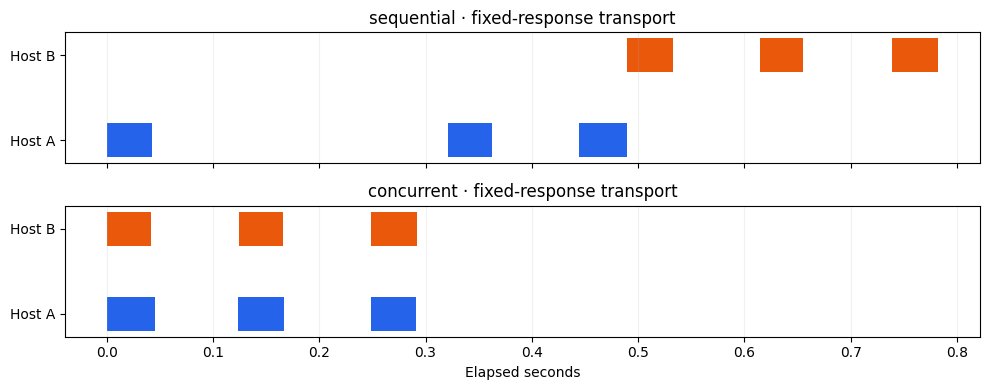

**해석:** 응답 집합이 같은 시험에서 순차 0.783초, 동시 0.292초였고 호스트 간격 위반은 0회였다. 이는 동시 대기 방식의 증거이며 실 네트워크의 속도 향상률은 아니다.

In [5]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
for ax, mode in zip(axes, ('sequential','concurrent')):
    for row, (host, spans) in enumerate(retry_evidence['concurrency'][mode + '_log'].items()):
        ax.broken_barh([(a, b-a) for a,b in spans], (row-.2, .4),
                      facecolors='#2563eb' if host == 'A' else '#ea580c')
    ax.set_yticks([0,1], ['Host A','Host B'])
    ax.set_title(mode + ' · fixed-response transport')
    ax.grid(axis='x', alpha=.18)
axes[-1].set_xlabel('Elapsed seconds')
fig.tight_layout()
(ROOT / 'reports/figures').mkdir(parents=True, exist_ok=True)
fig.savefig(ROOT / 'reports/figures/concurrency_gantt.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close(fig)
bench = retry_evidence['concurrency']
display(Markdown(f"**해석:** 응답 집합이 같은 시험에서 순차 {bench['sequential_s']:.3f}초, "
    f"동시 {bench['concurrent_s']:.3f}초였고 호스트 간격 위반은 {bench['interval_violations']}회였다. "
    '이는 동시 대기 방식의 증거이며 실 네트워크의 속도 향상률은 아니다.'))

<a id="etl-3"></a>

### ETL 3. 원본·정제·관측 분리와 계보

`raw_listing_page`는 요청 단위와 실패를 남긴다. 정제 공고는 플랫폼 자연키로 upsert하고, 관측 테이블은 공고가 실제 보인 실행·직무·페이지를 기록한다. `raw_id`와 실행 키를 통해 정제 결과를 원본으로 추적한다. 기술 키워드는 별도 테이블에 저장하고 플랫폼 간 중복 매핑은 `posting_canonical`에 남긴다.

**SQL 목적:** 원본과 정제의 저장 구조를 보여주고, 표본 정제 공고가 원본·시간별 관측·통합 ID에 연결되는지 검증한다. 원본 본문·인증 정보는 출력하지 않는다.

In [6]:
tables = query("SELECT table_name,table_type FROM information_schema.tables "
               "WHERE table_schema='public' ORDER BY table_type,table_name")
display(tables)
display(query("SELECT table_name,column_name,data_type FROM information_schema.columns "
    "WHERE table_schema='public' AND table_name IN ('raw_listing_page','job_posting','posting_snapshot') "
    "AND column_name IN ('raw_id','run_key','platform','posting_id','job_group','body','body_sha256','last_raw_id') "
    "ORDER BY table_name,ordinal_position"))
lineage_sql = '''SELECT s.run_key,s.raw_id,r.body_sha256,s.platform,s.posting_id,s.job_group,
       p.company_name,p.title,pc.canonical_id
FROM posting_snapshot s JOIN raw_listing_page r USING (raw_id)
JOIN job_posting p ON p.platform=s.platform AND p.posting_id=s.posting_id
LEFT JOIN posting_canonical pc ON pc.platform=p.platform AND pc.posting_id=p.posting_id
WHERE s.run_key=%s ORDER BY s.platform,s.posting_id,s.job_group LIMIT 8'''
lineage = sql_evidence(lineage_sql, (RUN_KEY,))
integrity = query('''SELECT count(*) AS observations,
    count(*) FILTER (WHERE r.raw_id IS NULL) AS missing_raw,
    count(*) FILTER (WHERE p.posting_id IS NULL) AS missing_master,
    count(*) FILTER (WHERE pc.canonical_id IS NULL) AS missing_canonical
FROM v_snapshot_scope s LEFT JOIN raw_listing_page r USING(raw_id)
LEFT JOIN job_posting p ON p.platform=s.platform AND p.posting_id=s.posting_id
LEFT JOIN posting_canonical pc ON pc.platform=s.platform AND pc.posting_id=s.posting_id''')
display(integrity)
assert integrity[['missing_raw','missing_master','missing_canonical']].to_numpy().sum() == 0

,table_name,table_type
0,crawl_run,BASE TABLE
1,job_canonical,BASE TABLE
2,job_posting,BASE TABLE
3,listing_metric,BASE TABLE
4,posting_canonical,BASE TABLE
5,posting_role,BASE TABLE
6,posting_skill,BASE TABLE
7,posting_snapshot,BASE TABLE
8,quality_check,BASE TABLE
9,raw_listing_page,BASE TABLE


,table_name,column_name,data_type
0,job_posting,platform,text
1,job_posting,posting_id,text
2,job_posting,last_raw_id,bigint
3,posting_snapshot,run_key,text
4,posting_snapshot,platform,text
5,posting_snapshot,job_group,text
6,posting_snapshot,posting_id,text
7,posting_snapshot,raw_id,bigint
8,raw_listing_page,raw_id,bigint
9,raw_listing_page,run_key,text


```sql
SELECT s.run_key,s.raw_id,r.body_sha256,s.platform,s.posting_id,s.job_group,
       p.company_name,p.title,pc.canonical_id
FROM posting_snapshot s JOIN raw_listing_page r USING (raw_id)
JOIN job_posting p ON p.platform=s.platform AND p.posting_id=s.posting_id
LEFT JOIN posting_canonical pc ON pc.platform=p.platform AND pc.posting_id=p.posting_id
WHERE s.run_key=%s ORDER BY s.platform,s.posting_id,s.job_group LIMIT 8
```

,run_key,raw_id,body_sha256,platform,posting_id,job_group,company_name,title,canonical_id
0,scheduled__2026-10-02T07:20:00+00:00,905,49ea89e1bb8276d967c56d64bee85d11208e5e5ca7dff754164256551760c338,incruit,2606130000077,DA,도쿄일렉트론코리아,도쿄일렉트론코리아 경력직 상시채용 공고_인재풀 등록,1
1,scheduled__2026-10-02T07:20:00+00:00,904,dc9ae7fb0b038bce7697aacd93bf332c708ccd96bebc1e2717c3f271017d39cf,incruit,2606130000077,DE,도쿄일렉트론코리아,도쿄일렉트론코리아 경력직 상시채용 공고_인재풀 등록,1
2,scheduled__2026-10-02T07:20:00+00:00,904,dc9ae7fb0b038bce7697aacd93bf332c708ccd96bebc1e2717c3f271017d39cf,incruit,2607060002877,DE,(주)안랩,[신입/경력] 디지털 포렌식,2
3,scheduled__2026-10-02T07:20:00+00:00,904,dc9ae7fb0b038bce7697aacd93bf332c708ccd96bebc1e2717c3f271017d39cf,incruit,2607070001094,DE,한화에어로스페이스,[한화에어로스페이스] AI 인력 상시 경력 채용,3
4,scheduled__2026-10-02T07:20:00+00:00,905,49ea89e1bb8276d967c56d64bee85d11208e5e5ca7dff754164256551760c338,incruit,2607230003578,DA,(주)이노션,AI 엔지니어 (Data/Analytics),4
5,scheduled__2026-10-02T07:20:00+00:00,905,49ea89e1bb8276d967c56d64bee85d11208e5e5ca7dff754164256551760c338,incruit,2608040003533,DA,(주)이노션,데이터 분석 및 컨설팅 (Junior) (상시채용 인재풀),5
6,scheduled__2026-10-02T07:20:00+00:00,904,dc9ae7fb0b038bce7697aacd93bf332c708ccd96bebc1e2717c3f271017d39cf,incruit,2608070000022,DE,삼양식품,[삼양식품] 글로벌 BI solution 개발 및 데이터 분석가,6
7,scheduled__2026-10-02T07:20:00+00:00,904,dc9ae7fb0b038bce7697aacd93bf332c708ccd96bebc1e2717c3f271017d39cf,incruit,2608070000036,DE,(주)쏘카,데이터 프로덕트 매니저,7


,observations,missing_raw,missing_master,missing_canonical
0,38208,0,0,0


<a id="etl-4"></a>

### ETL 4. 같은 원본 두 번 적재·다른 실행 키

원본의 목록 고유키와 정제 공고의 자연키를 유지한다. `first_seen`/`last_seen`은 최소·최대 관측 시각이며 게시 시각은 더 정밀한 값만 반영한다. 같은 실행의 관측·완전성 지표는 다시 만들어 parser 수정 후 replay가 가능하다.

아래는 저장 원본으로 실제 정제를 두 번 실행한 행 수다. 원본 행 수는 시험 실행 키만, 정제·관측은 전체 행을 센다. 다른 실행 키의 실험은 rollback하여 분석 범위에 남기지 않는다. canonical을 두 번 생성하여 행 수와 매핑 지문도 비교한다. [시험 코드](scripts/evidence.py)는 전체 시험 동안 정제·통합 advisory lock을 유지하여 운영 수집의 새 원본과 시험 결과를 구분한다.

In [7]:
from evidence import verify_idempotency
idempotency = verify_idempotency()
display(pd.DataFrame({'전': idempotency['before'], '1차': idempotency['after_first'],
    '2차': idempotency['after_second'], '2차 증가': idempotency['increase_second']}))
display(pd.DataFrame([{'다른 run 마스터 증가': idempotency['new_run_master_growth'],
    '실험 rollback': idempotency['experiment_rolled_back'],
    '통합 행 수(1·2차)': idempotency['dedup']['canonical_rows'],
    '통합 매핑 지문 동일': idempotency['dedup']['mapping_fingerprint_equal']}]))
assert all(n == 0 for n in idempotency['increase_second'].values())
assert idempotency['new_run_master_growth'] == 0
assert idempotency['experiment_rolled_back'] and idempotency['dedup']['mapping_fingerprint_equal']
display(Markdown('**해석:** 동일 원본 반복 실행은 행을 늘리지 않았다. 다른 실행 키는 '
    '별도의 시간 관측을 만들 수 있지만 플랫폼 공고 마스터는 증가하지 않았다.'))

,전,1차,2차,2차 증가
raw_listing_page,12,12,12,0
raw_posting_detail,0,0,0,0
job_posting,4942,4942,4942,0
posting_role,5772,5772,5772,0
posting_snapshot,38208,38208,38208,0
listing_metric,200,200,200,0
posting_skill,3154,3154,3154,0


,다른 run 마스터 증가,실험 rollback,통합 행 수(1·2차),통합 매핑 지문 동일
0,0,True,"[4549, 4549]",True


**해석:** 동일 원본 반복 실행은 행을 늘리지 않았다. 다른 실행 키는 별도의 시간 관측을 만들 수 있지만 플랫폼 공고 마스터는 증가하지 않았다.

<a id="etl-5"></a>

### ETL 5. 플랫폼 간 중복 통합 기준

정규화 회사명, 제목 유사도 `τ=0.55`, 마감일 양쪽 NULL 또는 3일 이내, 지역 호환을 함께 적용한다. 프론트/백엔드·리더/엔지니어 등 직무 충돌을 제외한다. 괄호의 팀·브랜드 제거에서 오탐이 발견되어 괄호 내용을 보존했다.

임계값별 통합 규모로 민감도를 확인한다. 고정 표본의 AI 육안 검토는 정답 라벨이 아니므로 실제 정밀도나 재현율을 단정할 수 없다. 모든 플랫폼 출처를 남겨 원공고를 확인할 수 있다.

In [8]:
from evidence import threshold_evidence
sensitivity = threshold_evidence()
display(pd.DataFrame(sensitivity['thresholds']))
review = json.loads((ROOT / 'reports/dedup_review.json').read_text())
display(pd.DataFrame(review['sample'])[['company_a','title_a','title_b','similarity','label','review']]
        .groupby('label', dropna=False).head(2))
print('고정 검토 표본:', review['label_counts'])
print('검토 한계:', review['limitation'])

,tau,candidate_pairs,canonical_groups,cross_posted,cross_posted_ratio
0,0.40,441,4516,386,0.085474
1,0.50,421,4535,374,0.082470
2,0.55,404,4549,367,0.080677
3,0.60,390,4563,357,0.078238
4,0.70,358,4593,333,0.072502


,company_a,title_a,title_b,similarity,label,review
0,네이버클라우드 주식회사,[NAVER Cloud] AI Security 분야 채용 (경력),AI Security 분야 채용 (경력),0.555556,True,"같은 공고일 가능성이 높음: 회사·핵심 직무·마감 일치, 표현/회사 접두어 차이"
1,(재)건설산업정보원,(재)건설산업정보원 연구원 채용(정보시스템 운영 및 관리),연구원 모집 (정보시스템 운영 및 관리),0.615385,True,"같은 공고일 가능성이 높음: 회사·핵심 직무·마감 일치, 표현/회사 접두어 차이"
3,㈜스카이즈코리아,(주) 스카이즈코리아 AI테크팀(부산) 채용,(주) 스카이즈코리아 AI테크팀 (서울) 채용,0.727273,False,"다른 공고: 부산 팀과 서울 팀, 근무지 차이. 지역 호환 조건 추가로 배제"
4,에스케이브로드밴드,2026년 하반기 SK브로드밴드 Junior Talent 채용,2026년 하반기 SK브로드밴드 Junior Talent 채용(AT/DT),0.785714,None,"불확실: Junior Talent 전체와 AT/DT 세부 직군, 동일 채용의 범위인지 확인 필요"


고정 검토 표본: {'likely_same': 18, 'different': 1, 'uncertain': 1}
검토 한계: 정답 데이터가 없으므로 실제 매칭 정밀도를 단정하지 않음. 조정 전 고정 표본을 보존.


<a id="etl-6"></a>

### ETL 6. 품질 규칙·결측 원인

원천 성공 비율, 필수 값, 개인정보 패턴, 날짜·경력 유효성, 직전 총건수 30% 변화와 실행 지연을 점검한다. 전체 원천 실패·개인정보는 critical, 개별 원천·개별 데이터 문제는 warning으로 격리한다. [규칙 원문](src/jobtrend/quality.py)과 `quality_check`에 판정 이력을 남긴다.

학력·고용 형태는 목록에 없으면 결측이고, 경력 무관은 연수 결측일 수 있다. 상시·채용시 마감의 날짜 NULL은 의미 있는 상태다. 미상과 상시를 구분해야 하며 결측을 임의의 숫자·날짜로 채우지 않는다.

In [9]:
missingness = query((ROOT / 'sql/missingness.sql').read_text())
validity = query((ROOT / 'sql/validity.sql').read_text())
display(missingness)
display(validity)
latest_quality = query('SELECT check_name,platform,dimension,metric,threshold,severity,detail '
    'FROM quality_check WHERE run_key=%s ORDER BY severity,check_name,platform', (RUN_KEY,))
display(latest_quality)
assert validity.required_missing.sum() == 0
assert validity.sentinel_leaks.sum() == 0
privacy = query("SELECT coalesce(sum(metric),0) AS n FROM quality_check q JOIN v_run_scope r USING(run_key) "
                "WHERE check_name='privacy_patterns'")
assert float(privacy.iloc[0].n) == 0
warning_count = int(latest_quality.severity.eq('warning').sum())
critical_count = int(latest_quality.severity.eq('critical').sum())
display(Markdown(f'**해석:** 필수 값 결측 {int(validity.required_missing.sum())}건, '
    f'상시 마감 sentinel 유출 {int(validity.sentinel_leaks.sum())}건, '
    f'개인정보 검출 {float(privacy.iloc[0].n):g}건이다. 마지막 실행의 warning은 {warning_count}개, '
    f'critical은 {critical_count}개다. 원천별 결측률 차이는 제공 필드 차이와 상세 수집 한도를 반영한다.'))

,platform,n,posted_at,sido,career_min_yr,education,deadline_unknown,meaningful_deadline_null,employment_type
0,incruit,169,0.000000,0.029586,0.195266,0.000000,0.000000,0.544379,0.000000
1,jobkorea,2049,0.000000,0.007321,0.194729,0.035139,0.011713,0.151293,0.013177
2,linkareer,120,0.000000,0.008333,0.441667,0.075000,0.000000,0.575000,0.733333
3,saramin,2604,0.040707,0.009217,0.215438,0.000000,0.000000,0.196621,0.000384


,platform,n,deadline_before_posted,invalid_career,sentinel_leaks,required_missing
0,incruit,169,0,0,0,0
1,jobkorea,2049,0,0,0,0
2,linkareer,120,0,0,0,0
3,saramin,2604,0,0,0,0


,check_name,platform,dimension,metric,threshold,severity,detail
0,change_reported_total,incruit:BE,change,0,0.3,ok,"{'cur': 62, 'prev': 62}"
1,change_reported_total,jobkorea:BE,change,0.001,0.3,ok,"{'cur': 1620, 'prev': 1621}"
2,change_reported_total,jobkorea:DA,change,0,0.3,ok,"{'cur': 130, 'prev': 130}"
3,change_reported_total,jobkorea:DE,change,0.003,0.3,ok,"{'cur': 380, 'prev': 381}"
4,change_reported_total,linkareer:IT,change,0,0.3,ok,"{'cur': 473, 'prev': 473}"
5,change_reported_total,saramin:BE,change,0,0.3,ok,"{'cur': 1780, 'prev': 1780}"
6,change_reported_total,saramin:DA,change,0.001,0.3,ok,"{'cur': 678, 'prev': 677}"
7,change_reported_total,saramin:DE,change,0.001,0.3,ok,"{'cur': 787, 'prev': 788}"
8,completeness_required,*,completeness,0,0,ok,{}
9,coverage_any_ok,*,coverage,12,1,ok,{}


**해석:** 필수 값 결측 0건, 상시 마감 sentinel 유출 0건, 개인정보 검출 0건이다. 마지막 실행의 warning은 0개, critical은 0개다. 원천별 결측률 차이는 제공 필드 차이와 상세 수집 한도를 반영한다.

<a id="etl-7"></a>

### ETL 7. Airflow·관측 커버리지·복구

`open_run → extract_raw → transform_load(all_done) → resolve_duplicates → check_quality → route → finish / alert_and_fail`

평일 09:00~20:00 KST의 10분 간격은 67틱이다. XCom은 요약만 전달하고 원본은 PostgreSQL에 저장한다. 실제 가동 전 오전 23틱은 좌절단으로 남긴다. 미래·진행 중·운영 중 누락을 분리하며, 없는 오전 관측을 사후 값으로 채우지 않는다.

13:50 실행에서는 구조화된 학력 JSON의 파싱 오류를 수정하고 보존 원본으로 재실행했다. 아래는 복구 기록과 해당 실행의 현재 상태다. DAG 구조는 로컬 커널과 실제 Airflow 컨테이너에서 각각 확인한다.

In [10]:
from test_dag import verify
schedule_evidence = verify()
container_test = 'import sys\nsys.path.insert(0, "/opt/airflow/dags")\n' + (ROOT / 'tests/test_dag.py').read_text()
container_run = subprocess.run(['docker','exec','-i','job-platform-pipeline-airflow-scheduler-1','python','-'],
    input=container_test, text=True, capture_output=True, check=True)
container_schedule = next(json.loads(line) for line in container_run.stdout.splitlines()
                          if line.startswith('{"ticks"'))
assert schedule_evidence['ticks'] == container_schedule['ticks'] == 67
assert set(schedule_evidence['tasks']) == set(container_schedule['tasks'])
display(pd.DataFrame([{'환경': '노트북 커널', **schedule_evidence},
                      {'환경': 'Airflow 컨테이너', **container_schedule}]))
dag_path = ROOT / 'src/jobtrend_dag.py'
deployed_dag = ROOT / 'airflow/dags/jobtrend_dag.py'
dag_source_equal = dag_path.read_bytes() == deployed_dag.read_bytes()
print('로컬/배포 DAG 파일 동일:', dag_source_equal)
assert dag_source_equal
display(pd.DataFrame([json.loads((ROOT / 'reports/deployment.json').read_text())]))

import operations
ops = operations.state()
display(pd.DataFrame(ops['counts'].items(), columns=['슬롯 상태','개수']).sort_values('슬롯 상태'))
problem_slots = pd.DataFrame(ops['slots'])
display(problem_slots[problem_slots.state.isin(['MISSING','FAILED','RUNNING','GRACE'])])
display(pd.DataFrame(ops['requests']))
print('점검 시각:', ops['checked_at'], '· DAG paused:', ops['dag_paused'],
      '· import 오류:', ops['import_errors'])
assert ops['import_errors'] == 0
recovery = json.loads((ROOT / 'reports/recovery.json').read_text())
display(pd.DataFrame([recovery]))
recovered = query('SELECT run_key,slot_ts,status,finished_at FROM crawl_run WHERE run_key=%s',
                  (recovery['run_id'],))
display(recovered)
assert len(recovered) == 1 and recovered.iloc[0].status in ('success','partial')
display(Markdown('**해석:** 좌절단은 가동 전 공백이며 운영 중 누락과 구별한다. '
    '13:50 파싱 실패는 원본이 남아 있어 재정제·재실행으로 복구할 수 있었다. '
    '현재 슬롯별 상태는 위 점검 시각의 결과다.'))

{"ticks": 67, "first": "2026-10-02T09:00:00+09:00", "last": "2026-10-02T20:00:00+09:00", "tasks": ["check_quality", "open_run", "extract_raw", "transform_load", "resolve_duplicates", "route", "alert_and_fail", "finish"], "max_active_runs": 1}


,환경,ticks,first,last,tasks,max_active_runs
0,노트북 커널,67,2026-10-02T09:00:00+09:00,2026-10-02T20:00:00+09:00,"[check_quality, open_run, extract_raw, transform_load, resolve_duplicates, route,...",1
1,Airflow 컨테이너,67,2026-10-02T09:00:00+09:00,2026-10-02T20:00:00+09:00,"[check_quality, open_run, extract_raw, transform_load, resolve_duplicates, route,...",1


로컬/배포 DAG 파일 동일: True


,files,code_version,running_after
0,20,25c37fd3771c,0


,슬롯 상태,개수
2,FUTURE,22
1,LEFT_TRUNCATED,23
0,SUCCESS,22


...

,platform,attempts,retried_pages
0,incruit,89,4
1,jobkorea,271,0
2,linkareer,109,0
3,saramin,217,1


점검 시각: 2026-10-02T16:28:40.978250+09:00 · DAG paused: False · import 오류: 0


,run_id,cause,action,api_status
0,scheduled__2026-10-02T04:50:00+00:00,educationRequirements JSON object,parse fix and rerun cached raw on latest version,200


,run_key,slot_ts,status,finished_at
0,scheduled__2026-10-02T04:50:00+00:00,2026-10-02 13:50:00+09:00,success,2026-10-02 14:44:09.293982+09:00


**해석:** 좌절단은 가동 전 공백이며 운영 중 누락과 구별한다. 13:50 파싱 실패는 원본이 남아 있어 재정제·재실행으로 복구할 수 있었다. 현재 슬롯별 상태는 위 점검 시각의 결과다.

<a id="etl-8"></a>

### ETL 8. 재현 경로·현재 검증 결과

정제와 DAG는 동일한 [jobtrend 패키지](src/jobtrend/)를 import한다. 원문을 반복 생성하는 셀 대신 모듈 파일과 지문을 남긴다. [수집](src/jobtrend/collect.py) · [HTTP](src/jobtrend/http.py) · [정제](src/jobtrend/transform.py) · [통합](src/jobtrend/dedup.py) · [DDL](src/jobtrend/schema.sql) · [DAG](src/jobtrend_dag.py) · [멱등 시험](scripts/evidence.py)

통합본 재현은 프로젝트 폴더에서 `python scripts/build_integrated_notebook.py`로 전체 셀을 한 새 커널에서 실행한다. 분리본 두 파일은 유지한다. 운영 환경 설정과 실행 방법은 README를 따른다. 노트북 실행 결과와 검증 JSON을 함께 보존한다.

금요일 하루·미가동 오전 공백·직무 코드의 범위 차이·동적으로 변하는 목록·중복 판정의 불확실성이 남는다. 20:00 슬롯을 확인하기 전에는 부분 데이터다. ETL 시험 성공과 하루 관측 완료를 별도로 표시한다.

In [11]:
manifest_paths = sorted((ROOT / 'src').rglob('*.py')) + sorted((ROOT / 'src').rglob('*.sql'))
manifest_paths += [ROOT / 'scripts/evidence.py', ROOT / 'tests/test_pipeline.py', ROOT / 'tests/test_dag.py']
manifest = [{'file': p.relative_to(ROOT).as_posix(), 'sha256': hashlib.sha256(p.read_bytes()).hexdigest()}
            for p in manifest_paths if '__pycache__' not in p.parts]
display(pd.DataFrame(manifest).assign(sha256=lambda df: df.sha256.str[:12]))
(ROOT / 'reports/source_manifest.json').write_text(json.dumps(manifest, ensure_ascii=False, indent=2))

final_slot = query("SELECT status FROM crawl_run WHERE run_kind='scheduled' "
                   "AND slot_ts=timestamptz '2026-10-02 20:00+09'")
finished = not final_slot.empty and final_slot.iloc[0].status in ('success','partial')
checks = {
    '4개 원천 실제 200·재파싱': set(smoke['원천']) == set(REGISTRY),
    '실패·동시성 7개 시험': retry_evidence['tests']['failures'] == retry_evidence['tests']['errors'] == 0,
    '원본·정제·통합 계보': integrity[['missing_raw','missing_master','missing_canonical']].to_numpy().sum() == 0,
    '2회 적재 증가 0': all(n == 0 for n in idempotency['increase_second'].values()),
    '다른 실행 키 rollback': idempotency['experiment_rolled_back'],
    '통합 매핑 멱등': idempotency['dedup']['mapping_fingerprint_equal'],
    '커널·컨테이너 67틱': schedule_evidence['ticks'] == container_schedule['ticks'] == 67,
    '필수 값·sentinel·개인정보': validity.required_missing.sum() == validity.sentinel_leaks.sum() == float(privacy.iloc[0].n) == 0,
    'DAG import 오류 0': ops['import_errors'] == 0,
    '13:50 실행 복구': recovered.iloc[0].status in ('success','partial'),
}
checks = {k: bool(v) for k,v in checks.items()}
assert all(checks.values()), checks
display(pd.DataFrame(checks.items(), columns=['검증 항목','통과']))
display(Markdown('**' + ('20:00 최종 슬롯 확인' if finished else '부분 수집 데이터 · 20:00 슬롯 대기')
    + '** · 관측 기준 ' + ASOF))
result = {'asof': ASOF, 'code_version': CODE_VERSION, 'final_slot': bool(finished),
          'checks': checks, 'coverage': ops['counts'], 'idempotency': idempotency,
          'dag_source_equal': dag_source_equal}
(ROOT / 'reports/etl_validation.json').write_text(json.dumps(result, ensure_ascii=False, indent=2, default=str))

,file,sha256
0,src/jobtrend/__init__.py,67f8fec2f84a
1,src/jobtrend/analysis.py,f1888d9a4acc
2,src/jobtrend/collect.py,c82d4e16e984
3,src/jobtrend/config.py,7de81c5a8bc0
4,src/jobtrend/dedup.py,ac442de4293f
5,src/jobtrend/http.py,a10a4c27df58
6,src/jobtrend/normalize.py,5826a4509c01
7,src/jobtrend/quality.py,931a9d42e266
8,src/jobtrend/runlog.py,e4b9d0cd6a5c
9,src/jobtrend/skills.py,977e75943a45


,검증 항목,통과
0,4개 원천 실제 200·재파싱,True
1,실패·동시성 7개 시험,True
2,원본·정제·통합 계보,True
3,2회 적재 증가 0,True
4,다른 실행 키 rollback,True
5,통합 매핑 멱등,True
6,커널·컨테이너 67틱,True
7,필수 값·sentinel·개인정보,True
8,DAG import 오류 0,True
9,13:50 실행 복구,True


**부분 수집 데이터 · 20:00 슬롯 대기** · 관측 기준 2026-10-02 16:20:00+09:00

1685

<a id="eda"></a>

## B. EDA

**분석 질문:** BE·DA·DE의 관측 공고 구성, 기술 키워드와 원천 간 중복은 어떻게 다른가?

2026-10-02 09:00~20:00 KST가 계획 범위이며 실제 수집은 12:50부터 시작했다. 오전 23틱은 좌절단이다. 20:00 전 출력은 부분 관측이고 빠진 시간의 값을 채우지 않는다.

분석 단위는 **통합 공고**다. 대표 조건은 게시 시각 정밀도·첫 관측·원천 순으로 한 공고를 선택한다. 기술·역량은 출처 합집합, 직무별 분모는 해당 직무의 통합 공고 수다. 복수 직무를 포함하므로 직무 합계는 전체 합계와 다를 수 있다. 중복 통합은 유사도에 따른 추정이며 실제 고용 인원·전체 시장 규모를 뜻하지 않는다.

In [12]:
from pathlib import Path
import os,sys,json
ROOT=Path.cwd()
assert (ROOT/'src/jobtrend').is_dir(), '프로젝트 루트에서 실행하세요'
sys.path.insert(0,str(ROOT/'src'))
from dotenv import load_dotenv
load_dotenv(ROOT/'.env')
from IPython.display import display,Markdown
import pandas as pd
from jobtrend import analysis as eda,store
pd.set_option('display.max_colwidth',90)
eda.setup_plots()
snapshot=eda.load_snapshot() # 모든 쿼리가 동일한 READ ONLY REPEATABLE READ 스냅샷
validation=eda.validate(snapshot)
catalog_evidence=eda.export_catalog(snapshot)
print('분석 기준 슬롯:',snapshot['asof'])
display(pd.DataFrame([catalog_evidence]))
print('SQL/pandas 독립 검증:',validation)
display(snapshot['catalog'].head(5)[['company_name','title','job_groups','sources','is_open']])

분석 기준 슬롯: 2026-10-02 16:20:00+09:00


,canonical_rows,platform_rows,source_links
0,4549,4942,4942


SQL/pandas 독립 검증: {'canonical_coverage': 4549, 'platform_postings': 4942, 'company_sql_pandas': True, 'window_sql_pandas': True, 'flow_sql_set_pandas': True, 'skill_sql_pandas': True}


,company_name,title,job_groups,sources,is_open
0,도쿄일렉트론코리아,도쿄일렉트론코리아 경력직 상시채용 공고_인재풀 등록,"[DA, DE]",[incruit],True
1,(주)안랩,[신입/경력] 디지털 포렌식,[DE],[incruit],True
2,한화에어로스페이스,[한화에어로스페이스] AI 인력 상시 경력 채용,[DE],[incruit],True
3,(주)이노션,AI 엔지니어 (Data/Analytics),[DA],[incruit],True
4,(주)이노션,[이노션] 데이터 분석 및 컨설팅 (Junior) (상시채용 인재풀),"[DA, DE]","[incruit, jobkorea]",True


<a id="eda-1"></a>

### EDA 1. 결측과 유효성부터 확인

**목적:** 원천이 제공하지 않는 값과 파싱 오류를 구분하고 비교 가능한 변수만 해석한다. 결측률은 플랫폼 공고 단위이며 통합 대표 조건의 결측률과 다르다. 상시·채용시 마감은 실제 날짜가 없으므로 의미 있는 NULL로 분리한다.

,platform,n,posted_at,sido,career_min_yr,education,deadline_unknown,meaningful_deadline_null,employment_type
0,incruit,169,0.0000,0.0296,0.1953,0.0000,0.0000,0.5444,0.0000
1,jobkorea,2049,0.0000,0.0073,0.1947,0.0351,0.0117,0.1513,0.0132
2,linkareer,120,0.0000,0.0083,0.4417,0.0750,0.0000,0.5750,0.7333
3,saramin,2604,0.0407,0.0092,0.2154,0.0000,0.0000,0.1966,0.0004


,platform,n,deadline_before_posted,invalid_career,sentinel_leaks,required_missing
0,incruit,169,0,0,0,0
1,jobkorea,2049,0,0,0,0
2,linkareer,120,0,0,0,0
3,saramin,2604,0,0,0,0


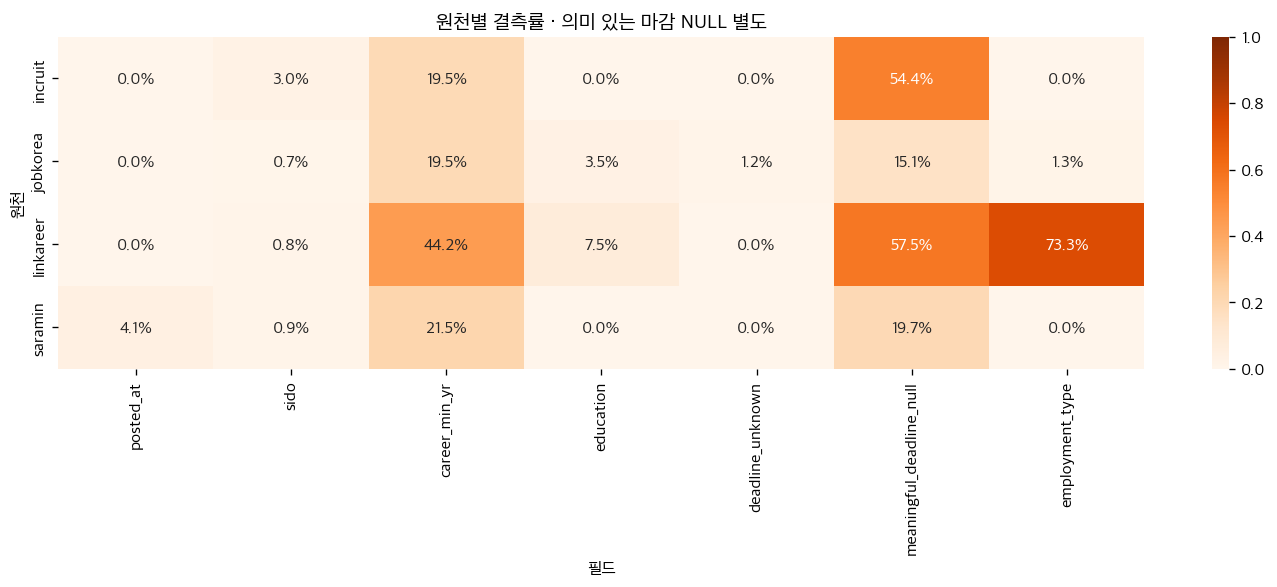

✍️ 목록이 제공하지 않는 학력·고용형태는 구조적 결측, 상시·채용시 마감일은 의미 있는 NULL, 상세 수집 대기와 수정 시각은 부분 결측, 양의 표시 총건수인데 파싱 0건인 경우는 파싱 실패로 구분한다. 매칭에 필요한 회사·제목·URL과 유효성 규칙을 별도로 점검했다.

In [13]:
display(snapshot['missingness'].round(4))
display(snapshot['validity'])
assert snapshot['validity'].sentinel_leaks.sum()==0
assert snapshot['validity'].required_missing.sum()==0
assert not ((snapshot['quality'].check_name=='privacy_patterns') & (snapshot['quality'].metric.astype(float)>0)).any()
display(Markdown(eda.chart_quality(snapshot)))

<a id="eda-2"></a>

### EDA 2. Q1·Q2 관측 공고의 변화

**목적:** 표시 총건수의 증감과 실제 목록 ID의 등장·이탈을 구분한다. Q1은 `LAG`·3슬롯 `AVG OVER`로 변화와 30분 평균을 계산한다. 링커리어는 혼합 IT 전수 목록에서 분류된 수이며 다른 플랫폼의 표시 총건수와 정의가 다르다. Q2는 연속 완료 전수의 `EXCEPT`로 유입·이탈을 계산한다. 첫 관측은 기준선으로만 사용한다.

차트는 실제 관측 구간만 표시하며 원천별 최초 관측=100 지수로 변화 크기를 비교한다. 오전 공백과 이후 예정 시간은 집계 표의 결측으로 유지한다. 목록 ID의 이탈은 채용 성사를 뜻하지 않는다.

In [14]:
for name in ('Q1','Q2'):
    display(Markdown('**'+name+' 집계 SQL**\n```sql\n'+eda.QUERIES[name].strip()+'\n```'))
q1=snapshot['Q1'];observed=q1[q1.inventory.notna()]
display(observed.groupby(['platform','job_group']).tail(1)[['platform','job_group','slot_ts','inventory','delta_10min','ma30']])
display(snapshot['Q2'][snapshot['Q2'].prev_slot.notna()].tail(12))

**Q1 집계 SQL**
```sql
WITH observed AS (
 SELECT m.platform,m.job_group,m.slot_ts,
  coalesce(m.reported_total,CASE WHEN m.is_complete THEN m.items_unique END)::numeric AS inventory,
  '표시 총건수/전수 ID'::text AS definition FROM v_listing_scope m WHERE job_group<>'MIX' AND status='ok'
 UNION ALL
 SELECT m.platform,g.job_group,m.slot_ts,
  CASE WHEN m.is_complete THEN (SELECT count(DISTINCT s.posting_id) FROM v_snapshot_scope s
    WHERE s.run_key=m.run_key AND s.platform=m.platform AND s.job_group=g.job_group) END::numeric,
  '혼합 목록 전수의 직무 분류' FROM v_listing_scope m CROSS JOIN (VALUES('BE'),('DA'),('DE')) g(job_group)
 WHERE m.job_group='MIX' AND m.status='ok'
), grid AS (
 SELECT s.slot_ts,k.platform,k.job_group,o.inventory,o.definition
 FROM generate_series(timestamptz '2026-10-02 09:00+09',timestamptz '2026-10-02 20:00+09',interval '10 minutes') s(slot_ts)
 CROSS JOIN (SELECT DISTINCT platform,job_group FROM observed) k
 LEFT JOIN observed o USING(slot_ts,platform,job_group)
), w AS (
 SELECT *,inventory-lag(inventory) OVER(PARTITION BY platform,job_group ORDER BY slot_ts) AS delta_10min,
  CASE WHEN count(inventory) OVER(PARTITION BY platform,job_group ORDER BY slot_ts ROWS BETWEEN 2 PRECEDING AND CURRENT ROW)=3
   THEN avg(inventory) OVER(PARTITION BY platform,job_group ORDER BY slot_ts ROWS BETWEEN 2 PRECEDING AND CURRENT ROW) END AS ma30,
  first_value(inventory) OVER(PARTITION BY platform,job_group ORDER BY (inventory IS NULL),slot_ts) AS baseline FROM grid
) SELECT *,100*inventory/nullif(baseline,0) AS idx100 FROM w ORDER BY platform,job_group,slot_ts
```

**Q2 집계 SQL**
```sql
WITH fulls AS (
 SELECT *,lag(run_key) OVER(PARTITION BY platform,query_key ORDER BY slot_ts) AS prev_run,
  lag(slot_ts) OVER(PARTITION BY platform,query_key ORDER BY slot_ts) AS prev_slot
 FROM v_listing_scope WHERE is_complete
), counts AS (
 SELECT f.platform,f.query_key,f.job_group,f.slot_ts,f.prev_slot,
  (SELECT count(DISTINCT posting_id) FROM v_snapshot_scope s WHERE s.run_key=f.run_key AND s.platform=f.platform AND s.query_key=f.query_key) AS current_n,
  (SELECT count(DISTINCT posting_id) FROM v_snapshot_scope s WHERE s.run_key=f.prev_run AND s.platform=f.platform AND s.query_key=f.query_key) AS previous_n,
  CASE WHEN f.prev_run IS NOT NULL THEN (SELECT count(*) FROM
   (SELECT DISTINCT posting_id FROM v_snapshot_scope s WHERE s.run_key=f.run_key AND s.platform=f.platform AND s.query_key=f.query_key
    EXCEPT SELECT DISTINCT posting_id FROM v_snapshot_scope s WHERE s.run_key=f.prev_run AND s.platform=f.platform AND s.query_key=f.query_key) a) END AS added,
  CASE WHEN f.prev_run IS NOT NULL THEN (SELECT count(*) FROM
   (SELECT DISTINCT posting_id FROM v_snapshot_scope s WHERE s.run_key=f.prev_run AND s.platform=f.platform AND s.query_key=f.query_key
    EXCEPT SELECT DISTINCT posting_id FROM v_snapshot_scope s WHERE s.run_key=f.run_key AND s.platform=f.platform AND s.query_key=f.query_key) a) END AS removed
 FROM fulls f
) SELECT *,sum(added) OVER(PARTITION BY platform,query_key ORDER BY slot_ts) AS cum_added,
 sum(removed) OVER(PARTITION BY platform,query_key ORDER BY slot_ts) AS cum_removed FROM counts ORDER BY platform,query_key,slot_ts
```

,platform,job_group,slot_ts,inventory,delta_10min,ma30
44,incruit,BE,2026-10-02 16:20:00+09:00,62,0,62.0000000000000000
111,incruit,DA,2026-10-02 16:20:00+09:00,82,0,82.0000000000000000
178,incruit,DE,2026-10-02 16:20:00+09:00,41,0,41.0000000000000000
245,jobkorea,BE,2026-10-02 16:20:00+09:00,1620,-1,1620.0000000000000000
312,jobkorea,DA,2026-10-02 16:20:00+09:00,130,0,130.0000000000000000
379,jobkorea,DE,2026-10-02 16:20:00+09:00,380,-1,380.3333333333333333
444,linkareer,BE,2026-10-02 16:00:00+09:00,65,None,None
511,linkareer,DA,2026-10-02 16:00:00+09:00,63,None,None
578,linkareer,DE,2026-10-02 16:00:00+09:00,19,None,None
647,saramin,BE,2026-10-02 16:20:00+09:00,1780,0,1779.6666666666666667


,platform,query_key,job_group,slot_ts,prev_slot,current_n,previous_n,added,removed,cum_added,cum_removed
71,saramin,BE,BE,2026-10-02 13:00:00+09:00,2026-10-02 12:50:00+09:00,1766,1766,0.0,0.0,0,0
72,saramin,BE,BE,2026-10-02 14:00:00+09:00,2026-10-02 13:00:00+09:00,1767,1766,9.0,8.0,9,8
73,saramin,BE,BE,2026-10-02 15:00:00+09:00,2026-10-02 14:00:00+09:00,1776,1767,10.0,1.0,19,9
74,saramin,BE,BE,2026-10-02 16:00:00+09:00,2026-10-02 15:00:00+09:00,1779,1776,6.0,3.0,25,12
76,saramin,DA,DA,2026-10-02 13:00:00+09:00,2026-10-02 12:50:00+09:00,673,673,0.0,0.0,0,0
77,saramin,DA,DA,2026-10-02 14:00:00+09:00,2026-10-02 13:00:00+09:00,676,673,3.0,0.0,3,0
78,saramin,DA,DA,2026-10-02 15:00:00+09:00,2026-10-02 14:00:00+09:00,676,676,1.0,1.0,4,1
79,saramin,DA,DA,2026-10-02 16:00:00+09:00,2026-10-02 15:00:00+09:00,677,676,3.0,2.0,7,3
81,saramin,DE,DE,2026-10-02 13:00:00+09:00,2026-10-02 12:50:00+09:00,785,785,0.0,0.0,0,0
82,saramin,DE,DE,2026-10-02 14:00:00+09:00,2026-10-02 13:00:00+09:00,787,785,4.0,2.0,4,2


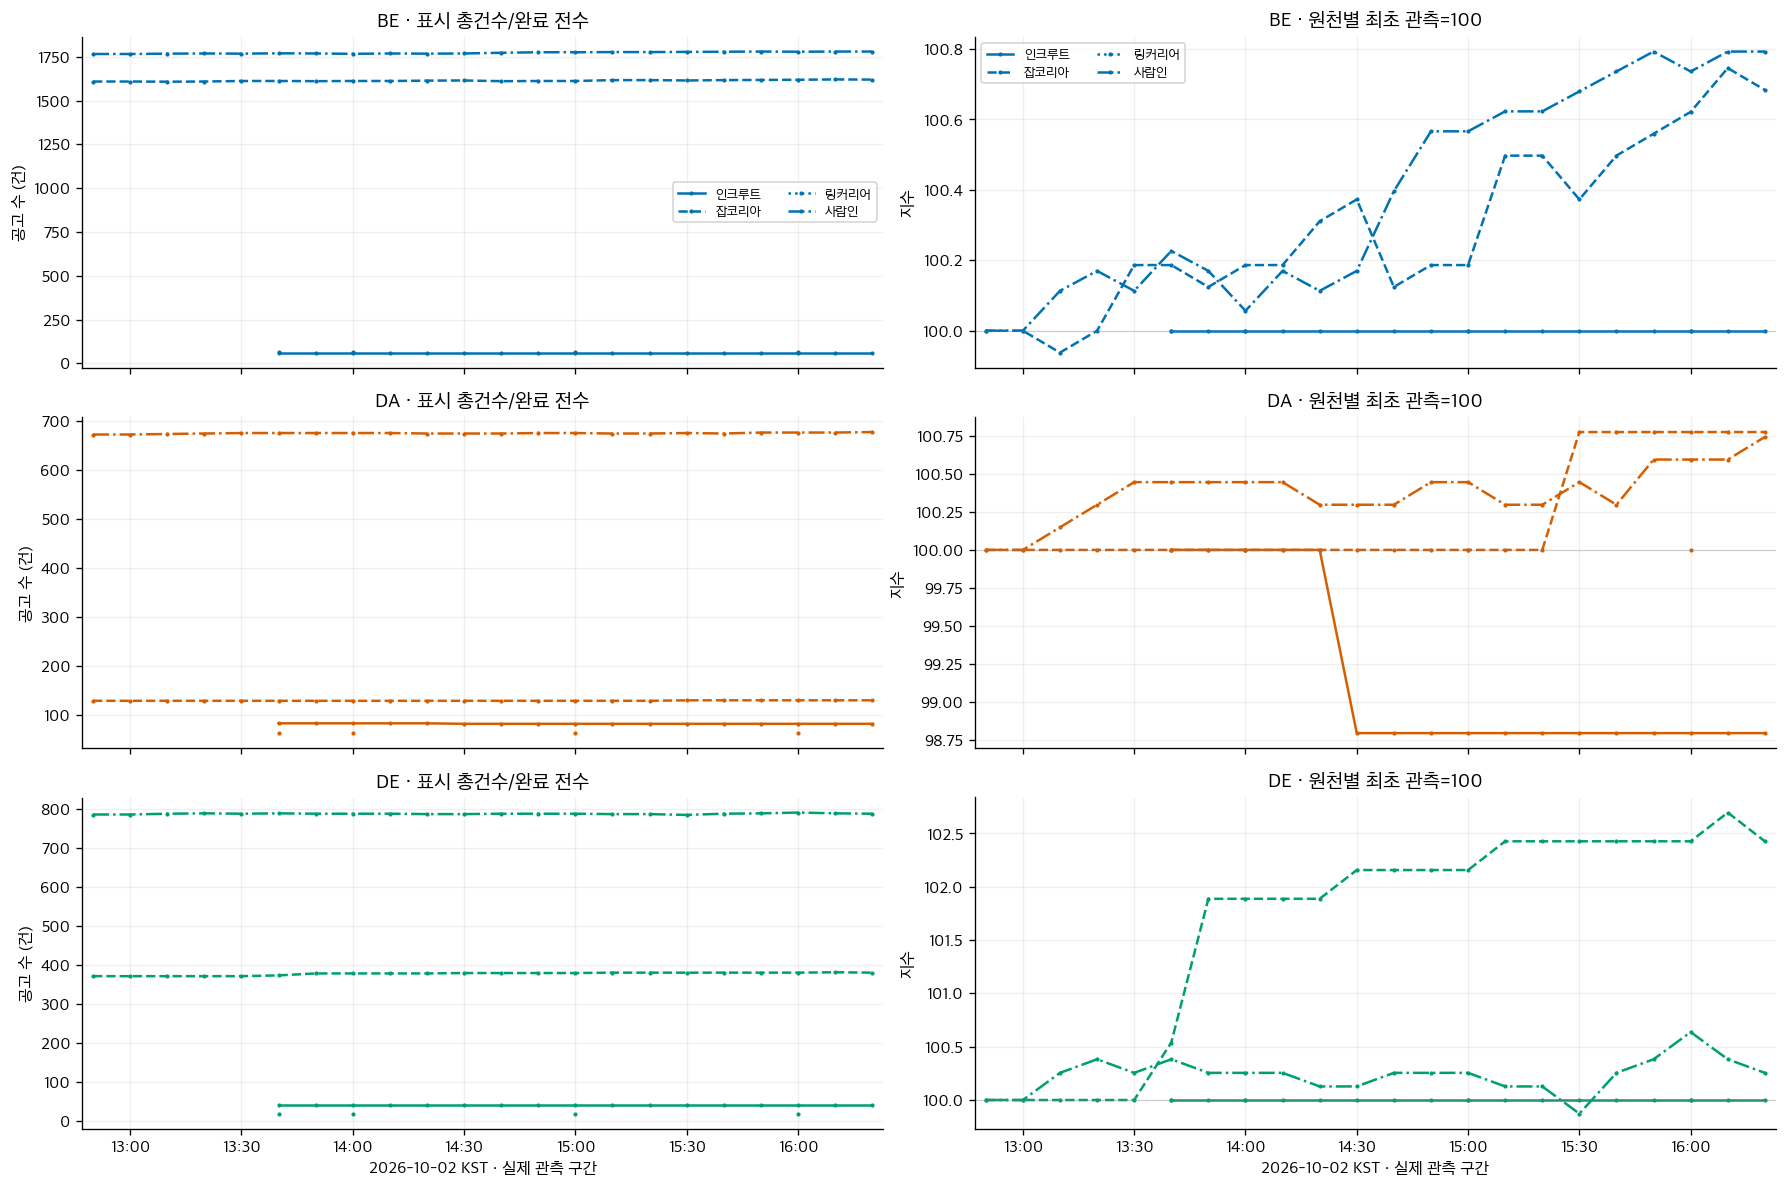

✍️ 확인된 원천·직무·슬롯 관측값은 195개다. 오전 가동 전과 아직 도래하지 않은 슬롯은 결측이며, 링커리어는 전수 스캔 시점의 분류 건수만 표시한다. 원천 간 총건수 정의가 달라 크기를 직접 시장 점유율로 해석할 수 없다.

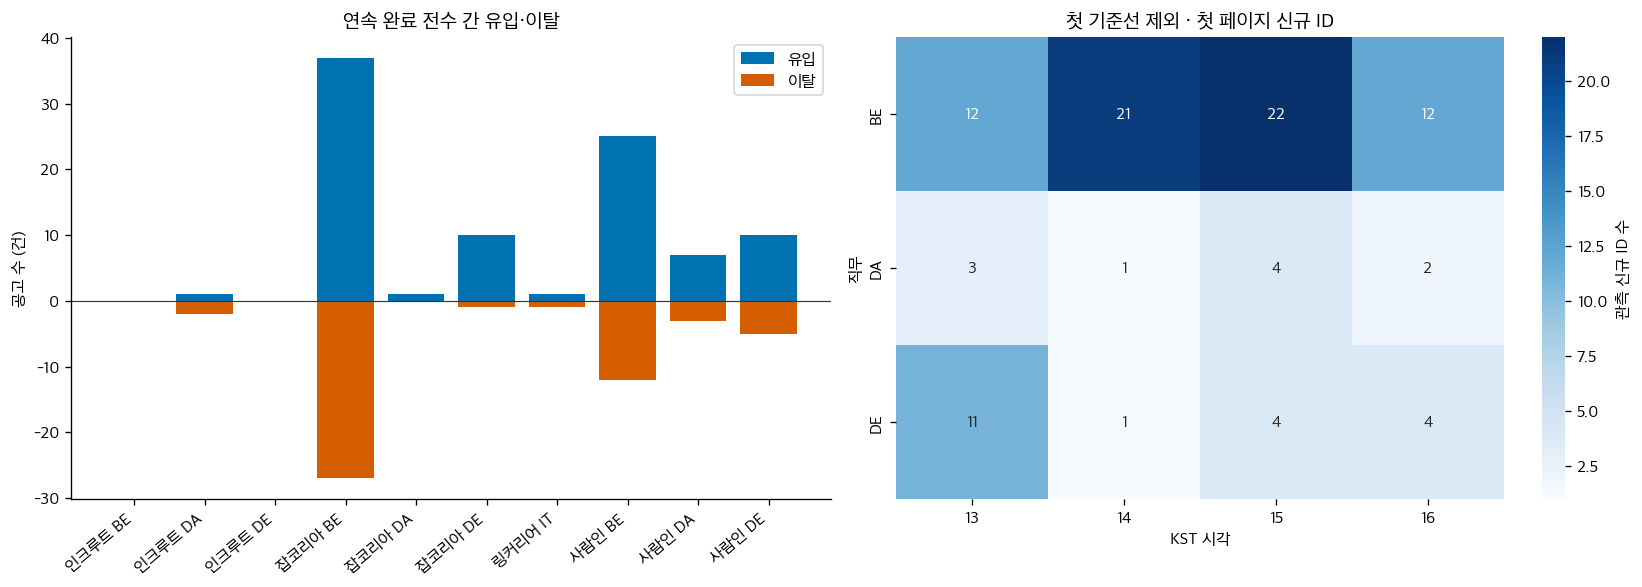

✍️ 비교 가능한 전수 간격 75개에서 유입 92건, 이탈 51건을 관측했다. 이는 최초 게시·실제 채용 성사 건수가 아니라 목록 ID의 등장·부재다. 같은 공고의 직무 중복과 시간 간격 차이가 있으므로 각 원천·질의 안에서 비교한다.

In [15]:
display(Markdown(eda.chart_q1(snapshot)))
display(Markdown(eda.chart_q2(snapshot)))

<a id="eda-3"></a>

### EDA 3. Q3·Q4 기업 집중도와 지원 조건

**목적:** 소수 기업의 다수 공고가 전체 수요를 부풀리는지 살펴보고 직무별 경력 문턱·지역·마감 구성을 비교한다. 회사명 정규화 후 `DENSE_RANK`·`NTILE`·누적 점유율로 집중도를 집계한다. 경력의 `PERCENTILE_CONT`는 결측을 제외한다. 대표 조건이 서로 다른 플랫폼에서 선택될 수 있으므로 원천별 결측을 함께 읽는다.

```sql
WITH company AS (SELECT c.company_key,min(j.company_name) company_name,count(*) n
 FROM v_job_scope j JOIN job_canonical c USING(canonical_id) GROUP BY c.company_key)
SELECT *,dense_rank() OVER(ORDER BY n DESC) ranking, ntile(20) OVER(ORDER BY n DESC,company_key) bucket20,
 n::numeric/sum(n) OVER() AS share, sum(n) OVER(ORDER BY n DESC,company_key ROWS UNBOUNDED PRECEDING)::numeric/sum(n) OVER() AS cum_share
FROM company ORDER BY n DESC,company_key
```

,company_name,n,ranking,share,cum_share
0,(주)사람인에이치에스,33,1,0.00725434161354143768,0.00725434161354143768
1,메가존클라우드,31,2,0.00681468454605407782,0.01406902615959551550
2,넛지헬스케어 주식회사,27,3,0.00593537041107935810,0.02000439657067487360
3,조인아이티,22,4,0.00483622774236095845,0.02484062431303583205
4,넥스트증권 주식회사,16,5,0.00351725653989887887,0.02835788085293471093
5,인터엑스,14,6,0.00307759947241151902,0.03143548032534622994
6,휴먼코어랩(주),14,6,0.00307759947241151902,0.03451307979775774896
7,카카오페이,13,7,0.00285777093866783909,0.03737085073642558804
8,(주)이테크시스템,13,7,0.00285777093866783909,0.04022862167509342713
9,카카오,12,8,0.00263794240492415916,0.04286656408001758628


,job_group,career_type,n,share,median_min_years
0,BE,any,422,0.12921004286589099816,NaN
1,BE,exp,2354,0.72075933864053888549,4.0
2,BE,new,146,0.04470300061236987140,0.0
3,BE,new_or_exp,338,0.10349050826699326393,0.0
4,BE,unknown,6,0.00183710961420698102,NaN
5,DA,any,208,0.22174840085287846482,NaN
6,DA,exp,525,0.55970149253731343284,3.0
7,DA,new,66,0.07036247334754797441,0.0
8,DA,new_or_exp,126,0.13432835820895522388,0.0
9,DA,unknown,13,0.01385927505330490405,NaN


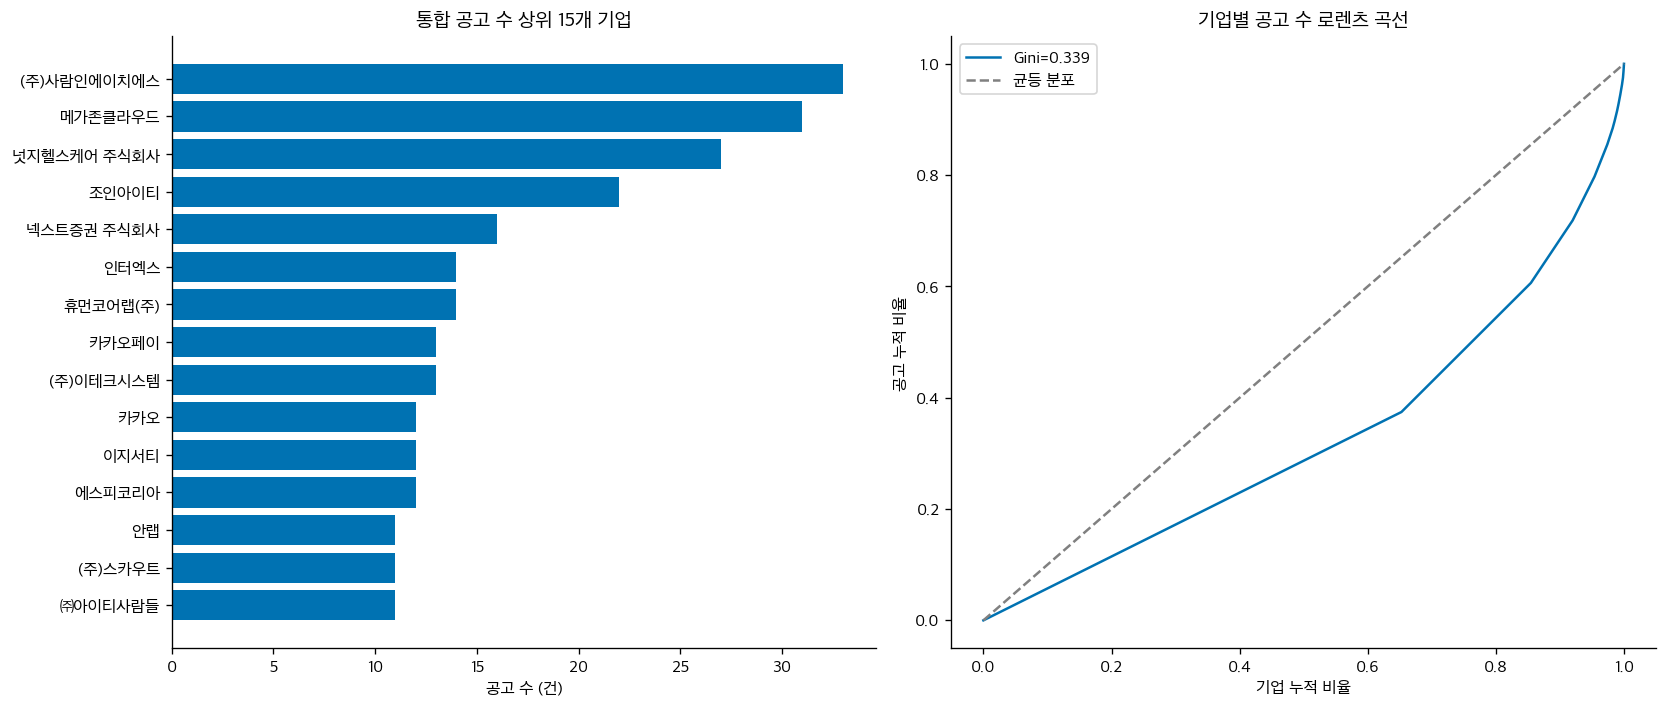

✍️ 정규화 기업 2,608개 중 상위 5%의 공고 점유율은 21.3%, 상위 10%는 31.6%, Gini는 0.339다. 헤드헌팅 업체와 다직무 공고가 포함돼 기업 공고 수가 고용 인원을 뜻하지 않는다.

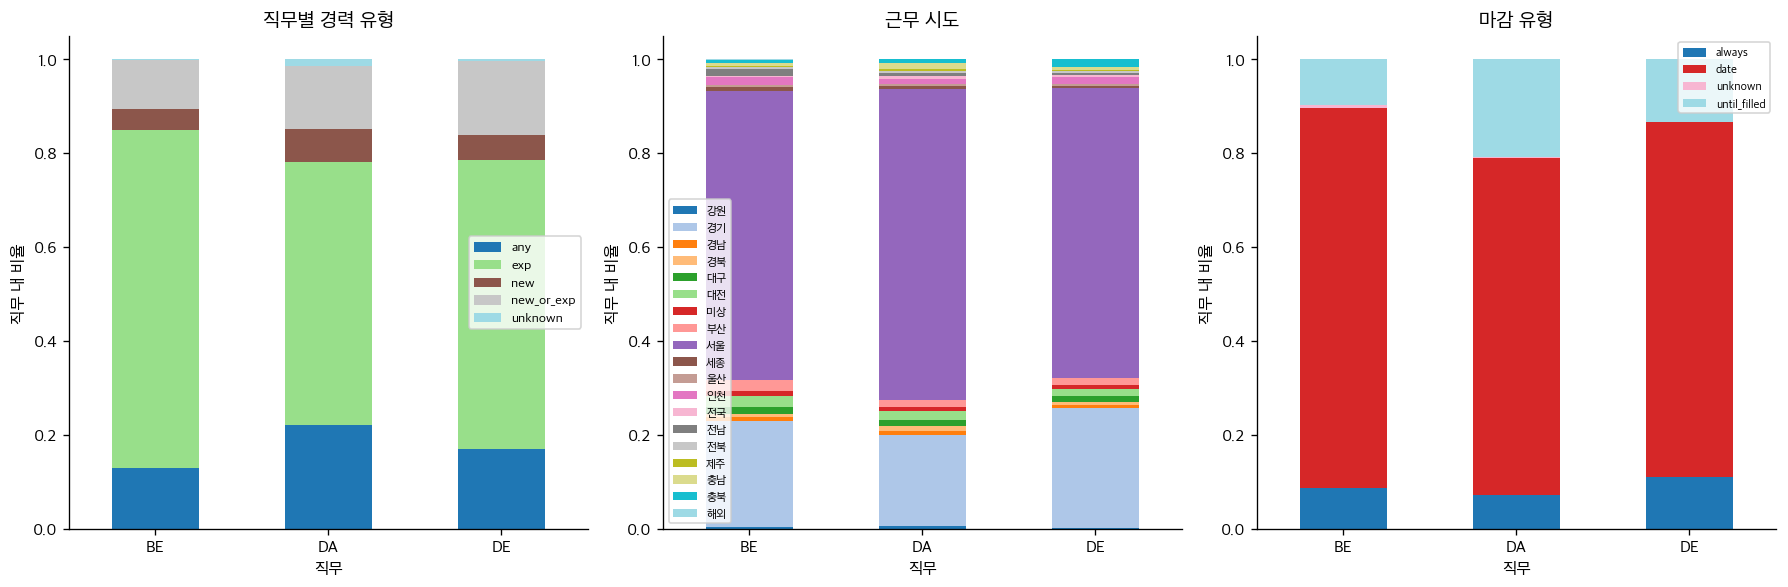

✍️ 신입을 포함하는 공고 비율은 BE 14.8%, DA 20.5%, DE 21.0%다. 대표 공고 기준 수도권 비율은 86.7%이며 지역 결측도 분모에 포함했다. 직무가 여러 개인 통합 공고는 각 직무 안에서 한 번씩 집계한다.

In [16]:
display(Markdown('```sql\n'+eda.QUERIES['Q3'].strip()+'\n```'))
display(snapshot['Q3'].head(10)[['company_name','n','ranking','share','cum_share']])
display(snapshot['Q4'])
display(Markdown(eda.chart_q3(snapshot)))
display(Markdown(eda.chart_q4(snapshot)))

<a id="eda-4"></a>

### EDA 4. Q5 게시일 분포와 Q6 중복 게시

**목적:** 현재 목록에 남아 있는 오래된 공고의 영향을 확인하고 플랫폼 중복을 통합한 효과를 측정한다. 게시일 분포는 과거 채용 수요의 시계열이 아니다. 상대 시각은 최초 관측 기준으로 고정하고 수정 표기와 구분한다.

중복 기준은 회사·제목 유사도 0.55·호환 마감·지역과 직무 충돌 제외다. [ETL](#etl)의 임계값 민감도와 표본 검토가 이 추정의 한계를 설명한다. 모든 원천 링크를 보존하여 직접 검토할 수 있다.

,통합 공고 수
posted_precision,
day,4026
hour,233
second,120
none,99
minute,71


,sources,n_sources,n,share
0,[saramin],1,2242,0.49285557265333040229
1,[jobkorea],1,1690,0.37151022202681908112
2,"[jobkorea, saramin]",2,332,0.07298307320290173665
3,[incruit],1,145,0.03187513739283358980
4,[linkareer],1,105,0.02308199604308639261
5,"[incruit, saramin]",2,10,0.00219828533743679930
6,"[incruit, jobkorea]",2,6,0.00131897120246207958
7,"[linkareer, saramin]",2,6,0.00131897120246207958
8,"[jobkorea, linkareer, saramin]",3,5,0.00109914266871839965
9,"[incruit, jobkorea, saramin]",3,4,0.00087931413497471972


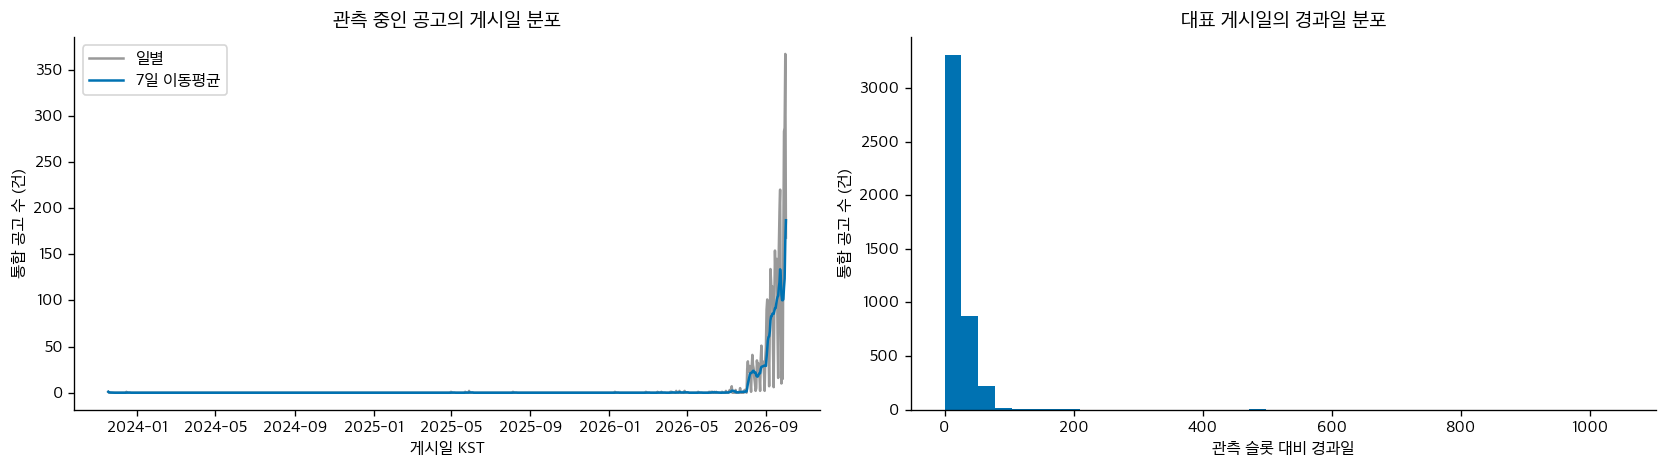

✍️ 대표 게시 시각 결측률은 2.2%다. 게시일 분포는 이번에 목록에 남아 있던 공고의 분포이며 과거 일별 채용 수요 추이가 아니다. 상대 시각은 첫 관측 값으로 고정했고, 등록과 수정 표기는 구분했다.

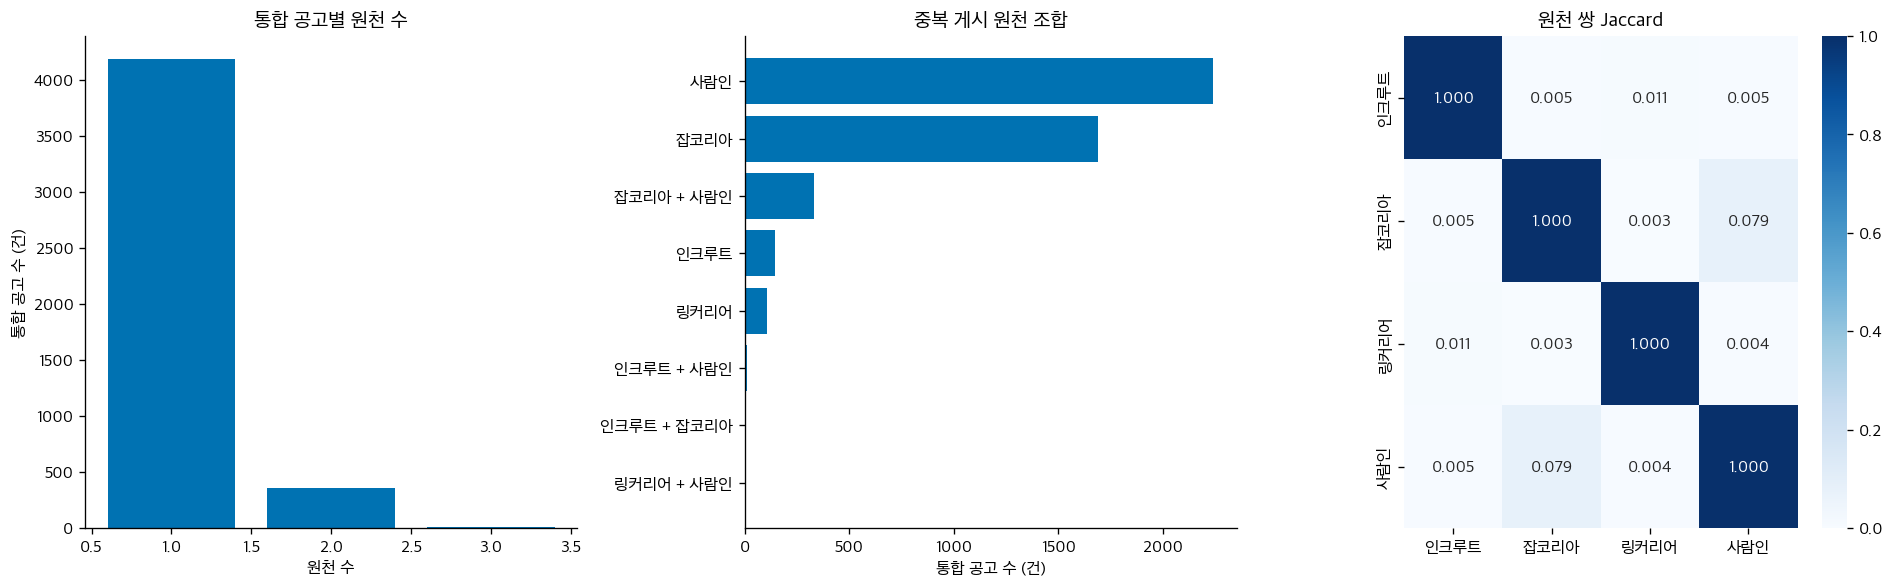

✍️ 현재 판정에서 여러 원천에 게시된 통합 공고는 367건(8.1%)이다. 회사·제목·마감이 호환되는 후보를 묶은 추정치이며, 임계값별 민감도와 표본 검토를 함께 읽어야 한다. 링크 4,942개를 전체 목록에 보존했다.

In [17]:
display(snapshot['features'].posted_precision.value_counts(dropna=False).rename('통합 공고 수').to_frame())
display(snapshot['Q6'])
display(Markdown(eda.chart_q5(snapshot)))
display(Markdown(eda.chart_q6(snapshot)))

<a id="eda-5"></a>

### EDA 5. Q7 기술·역량과 직무별 특이성

**목적:** 통합 공고별 키워드를 한 번만 세어 원천 중복으로 빈도가 부풀려지는 것을 막는다. 직무 점유율을 전체 점유율로 나눈 Lift는 해당 직무에서 상대적으로 자주 검출된 기술을 보여준다. 사전 별칭과 경계를 사용하며 JavaScript를 Java로 세지 않는 시험은 ETL에 있다.

목록 태그·제목·읽을 수 있는 상세 텍스트만 사용한다. 이미지 공고와 사전 밖 표현은 검출하지 못하므로 키워드 미검출을 요구 없음으로 해석하지 않는다. 의미 없는 명사 후보 나열과 자동 사전 확대는 제외했다.

```sql
WITH r AS (SELECT DISTINCT x.canonical_id,r.job_group FROM posting_role r JOIN posting_canonical x USING(platform,posting_id) JOIN v_job_scope j USING(canonical_id)),
 s AS (SELECT DISTINCT x.canonical_id,sk.skill,sk.skill_group FROM posting_skill sk JOIN posting_canonical x USING(platform,posting_id) JOIN v_job_scope j USING(canonical_id)),
 freq AS (SELECT r.job_group,s.skill,s.skill_group,count(*) n FROM r JOIN s USING(canonical_id) GROUP BY 1,2,3),
 denom AS (SELECT job_group,count(*) n FROM r GROUP BY 1),overall AS (SELECT skill,count(*) n FROM s GROUP BY 1)
SELECT f.*,f.n::numeric/d.n AS share,(f.n::numeric/d.n)/(o.n::numeric/(SELECT count(*) FROM v_job_scope)) AS lift
FROM freq f JOIN denom d USING(job_group) JOIN overall o USING(skill) ORDER BY job_group,n DESC,skill
```

,job_group,skill,n,share,lift
0,BE,Java,510,0.15615431720759338641,1.35821412806375203590
1,BE,AWS,128,0.03919167176974892835,1.18068155550058195399
3,BE,Spring,105,0.03214941824862216779,1.37969531710360604998
4,BE,Python,104,0.03184323331292100429,0.83249924333607843974
5,BE,C#,88,0.02694427434170238824,1.26360313381859962973
54,DA,Python,55,0.05863539445628997868,1.53294488150381099434
55,DA,SQL,45,0.04797441364605543710,2.69426676143094053572
61,DA,AWS,18,0.01918976545842217484,0.57810757000240048571
63,DA,Java,13,0.01385927505330490405,0.12054654343687190922
64,DA,MySQL,12,0.01279317697228144989,0.92374860391917961178


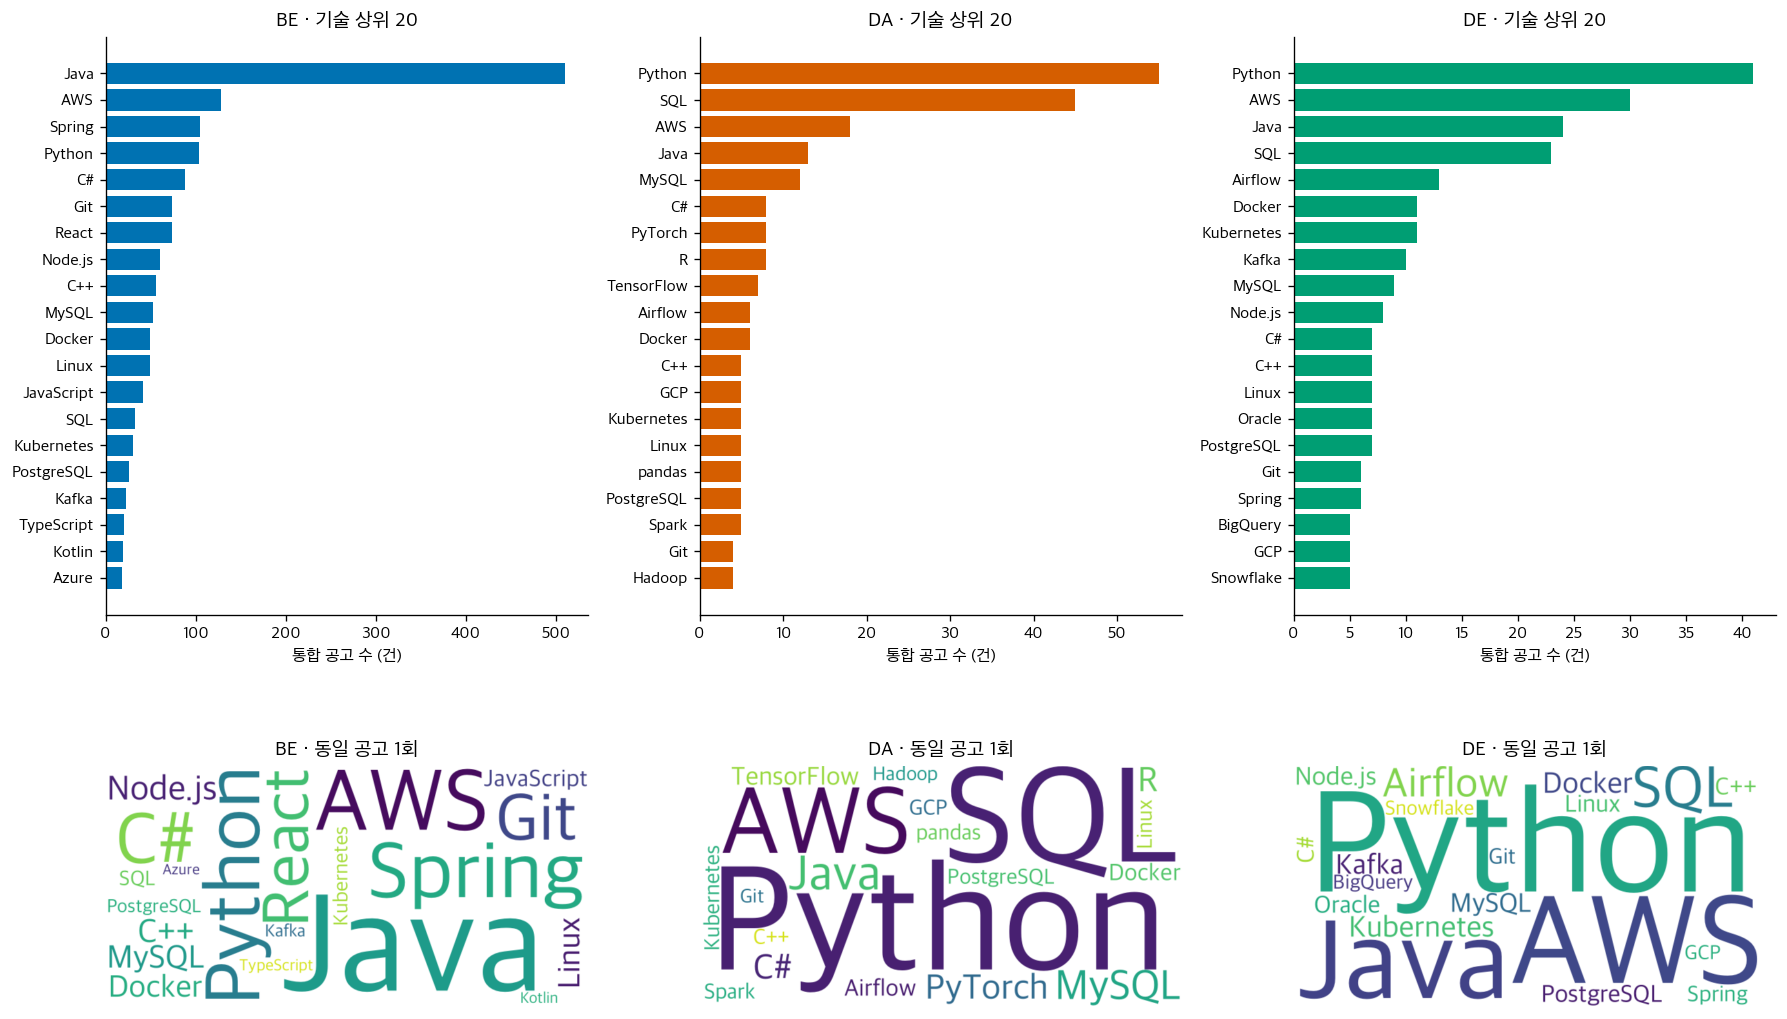

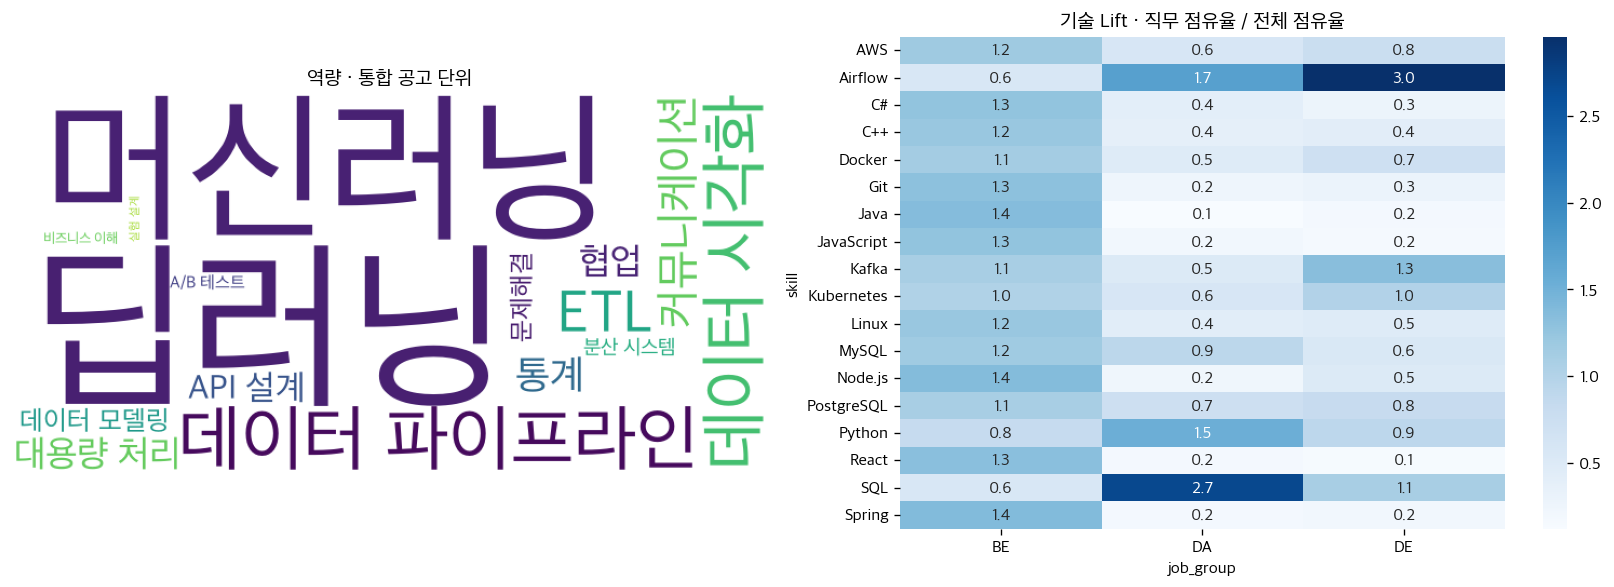

✍️ 기술 키워드가 한 개 이상 검출된 통합 공고는 24.8%다. 제목·목록 태그와 읽을 수 있는 상세 텍스트를 사전으로 검색한 결과다. 이미지로만 제공된 자격요건과 사전 밖 표현은 관측하지 못하므로 미검출이 요구 없음으로 해석되지 않는다. 워드클라우드의 크기는 수요 인원이 아니라 공고 빈도다.

In [18]:
display(Markdown('```sql\n'+eda.QUERIES['Q7'].strip()+'\n```'))
display(snapshot['Q7'][snapshot['Q7'].skill_group.eq('technology')].groupby('job_group').head(5)[['job_group','skill','n','share','lift']])
display(Markdown(eda.chart_q7(snapshot)))

<a id="eda-6"></a>

### EDA 6. Q8 상관과 공출현

**목적:** 경력·키워드 수·게시 경과일 등의 동반 변화를 탐색한다. Spearman은 유효 쌍 30개 이상과 비상수 변수에만 계산한다. 상위 기술 공출현은 통합 공고의 이진 지표로 Phi를 계산한다. 범주 검정은 단일 직무 공고만 사용하고 기대빈도 5 미만이면 p값을 보류한다.

상관 쌍의 n·p·BH FDR 보정 q값을 CSV에 보존한다. 시차 상관은 연속 변화량 표본이 충분할 때만 그림을 만든다. 검정은 탐색적이며 인과관계나 직무 효과를 확정하지 않는다.

,variables,n,chi2,p,cramers_v,min_expected,p_valid
0,role × career_type,3856,126.5961,NaN,0.1281,1.3849,False
1,role × region,3856,18.3608,0.0054,0.0488,8.3091,True
2,platform × career_type,3856,704.9726,NaN,0.2469,0.2707,False
3,cross_posted × role,3856,41.2290,0.0000,0.1034,32.3133,True


,A,B,n,rho,p,q_BH
0,career_min_yr,career_max_yr,937,0.8025,0.0000,0.0000
21,days_to_deadline,posted_age_days,3513,-0.3139,0.0000,0.0000
28,posted_age_days,always_open,4450,0.1487,0.0000,0.0000
6,career_min_yr,company_postings,3578,0.1343,0.0000,0.0000
17,skill_count,n_sources,4549,0.1213,0.0000,0.0000
18,skill_count,title_length,4549,0.1198,0.0000,0.0000
34,company_postings,always_open,4549,0.1042,0.0000,0.0000
3,career_min_yr,posted_age_days,3499,-0.1040,0.0000,0.0000
9,career_max_yr,days_to_deadline,750,-0.0996,0.0064,0.0171
30,n_sources,company_postings,4549,-0.0851,0.0000,0.0000


유효 시차 결과: 25 개 · 0개이면 시차 그림 제외


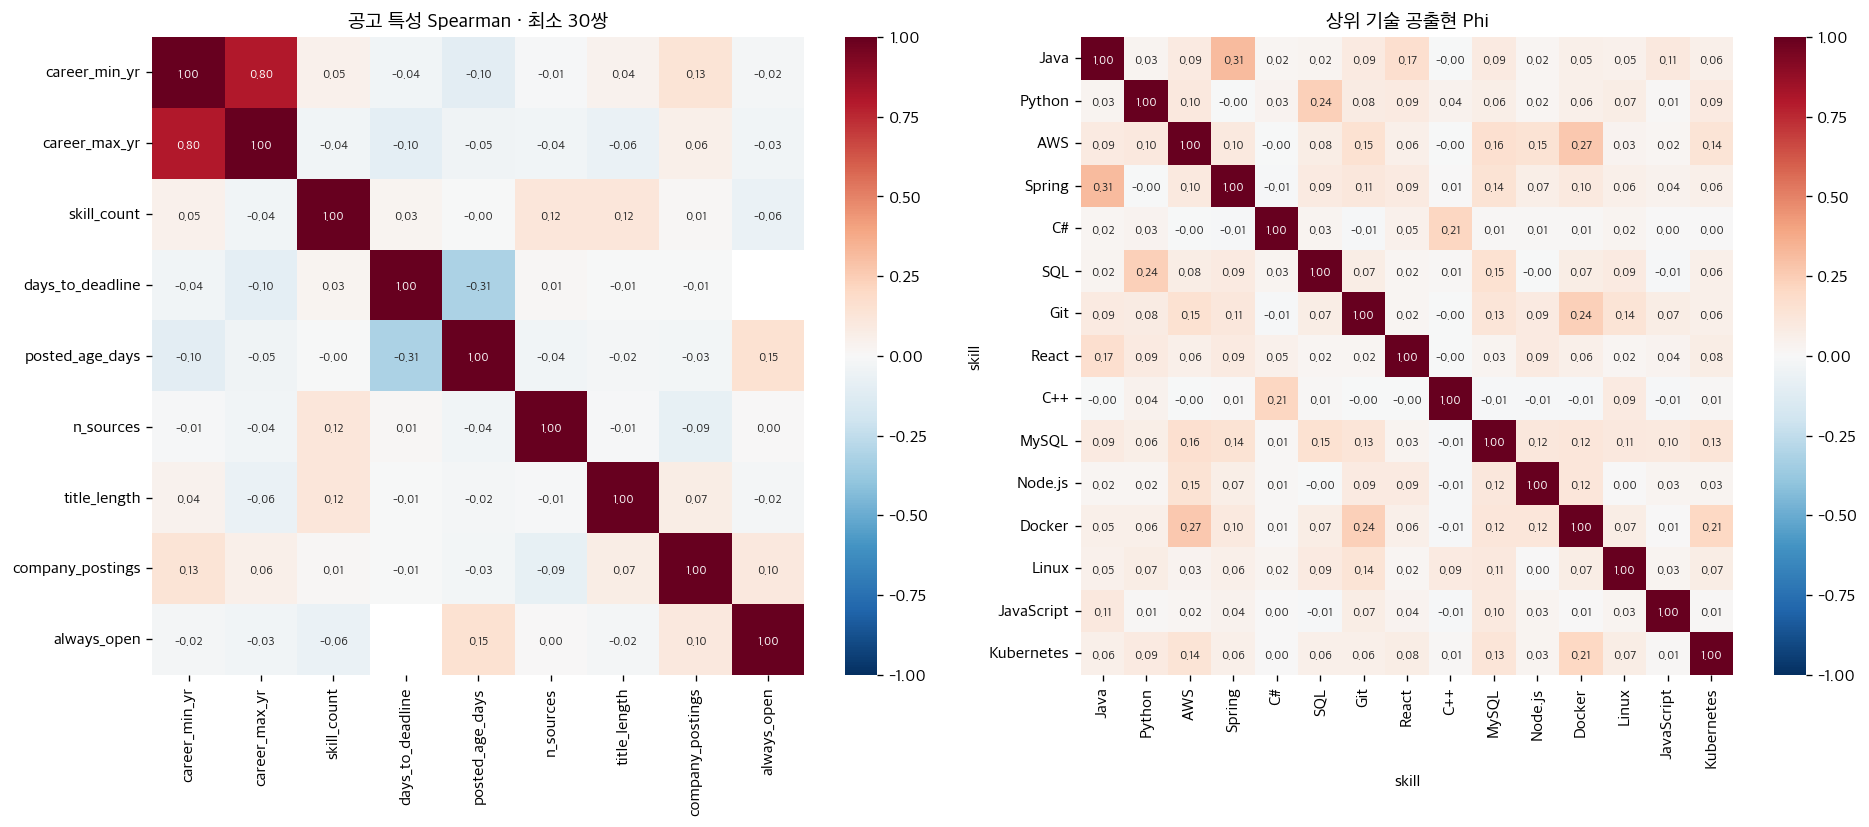

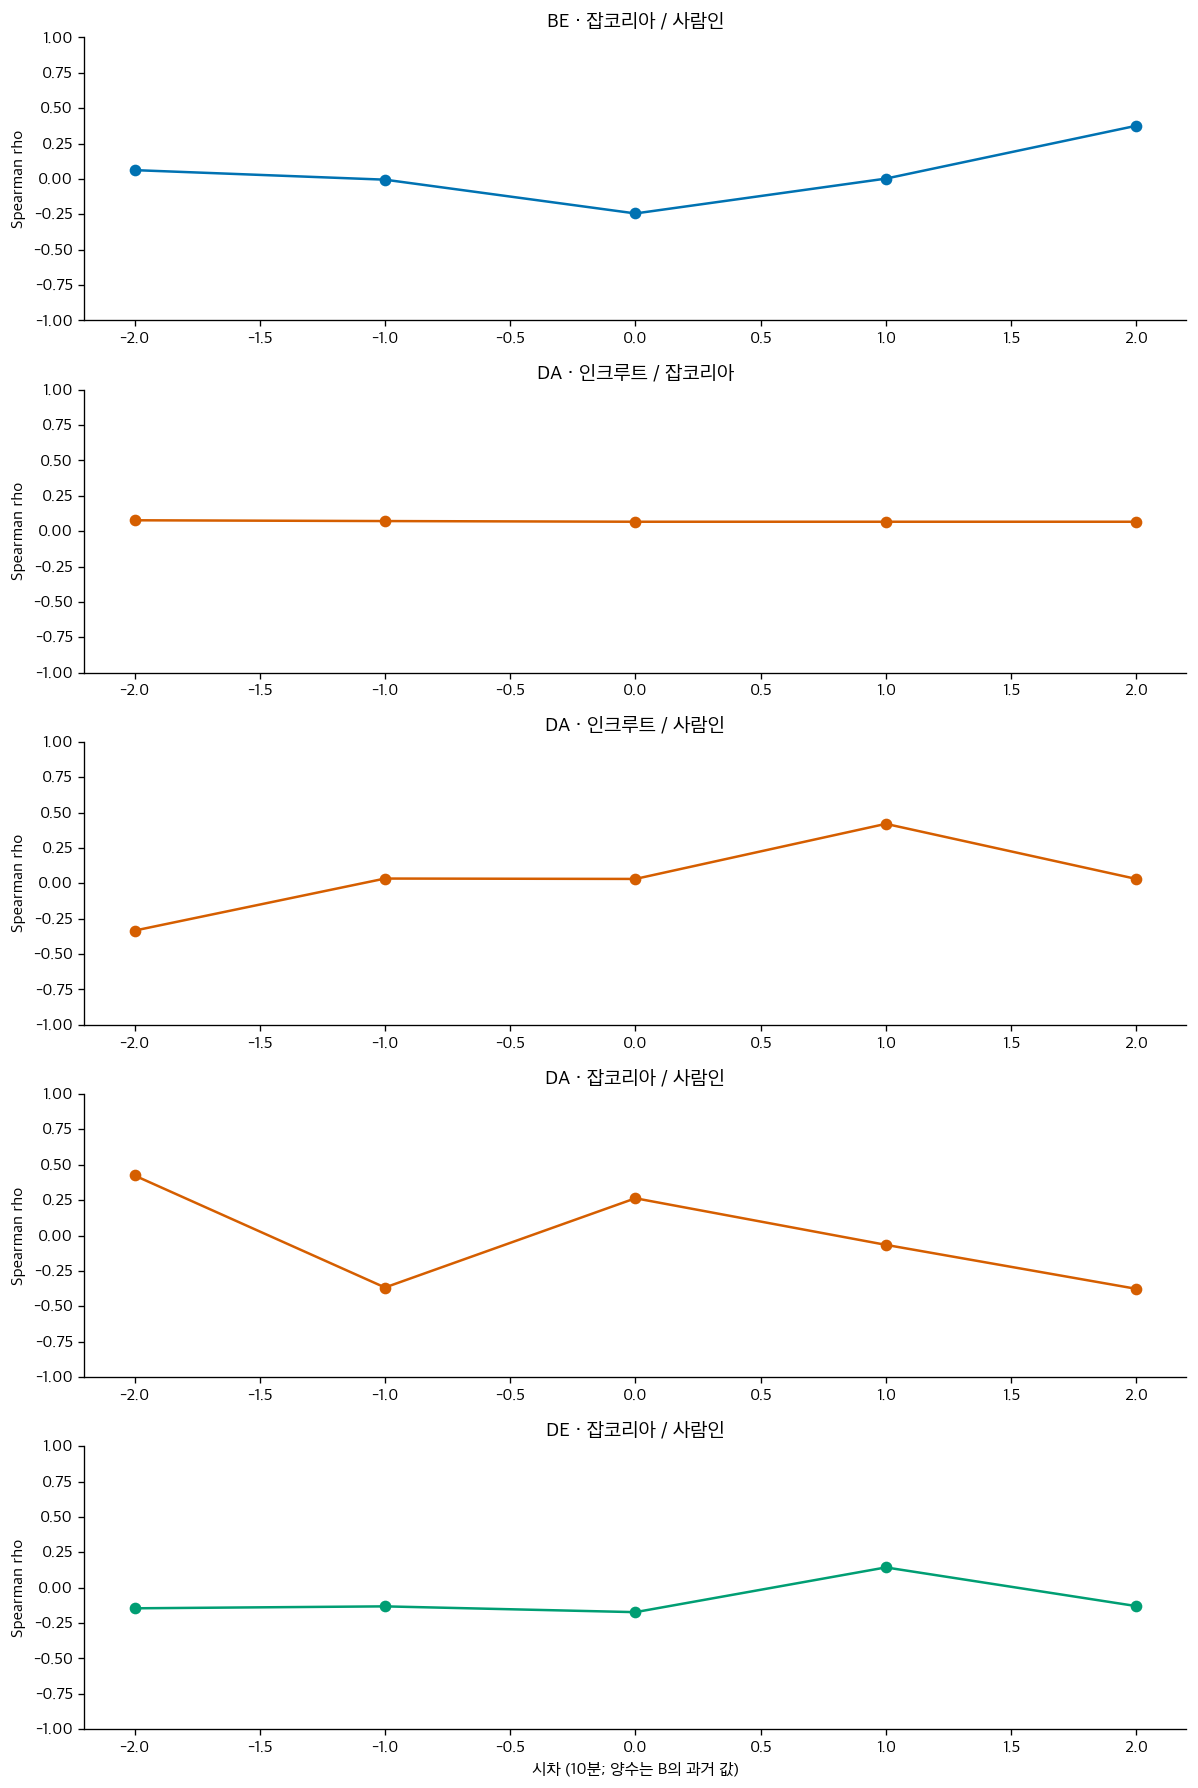

✍️ 상관은 인과관계를 뜻하지 않는다. p값·유효 쌍 수·상관 쌍의 BH FDR 보정 q값을 CSV에 보존하고 결측을 쌍별로 제외했다. 범주 검정은 단일 직무 공고만 사용해 복수 직무 693건을 제외했으며 기대빈도 5 미만인 검정의 p값은 보류한다. 범주 검정은 보정 전 탐색 통계이며, 어느 결과도 확증적 인과 결론으로 사용하지 않는다.

In [19]:
stats8=eda.stats_q8(snapshot)
display(stats8['associations'].round(4))
pair_rows=[]
for i,a in enumerate(stats8['rho'].columns):
    for b in stats8['rho'].columns[i+1:]:
        rho=stats8['rho'].loc[a,b]
        if pd.notna(rho):pair_rows.append({'A':a,'B':b,'n':int(stats8['n'].loc[a,b]),'rho':rho,'p':stats8['p'].loc[a,b],'q_BH':stats8['qvalue'].loc[a,b]})
pairs=pd.DataFrame(pair_rows)
if not pairs.empty:display(pairs.assign(abs_rho=pairs.rho.abs()).sort_values('abs_rho',ascending=False).drop(columns='abs_rho').head(10).round(4))
print('유효 시차 결과:',int(stats8['lags'].rho.notna().sum()), '개 · 0개이면 시차 그림 제외')
display(Markdown(eda.chart_q8(snapshot,stats8)))

<a id="eda-7"></a>

### EDA 7. Q9 분포와 이상치 판단

**목적:** 기업당 공고 수·최소 경력·마감까지 일수 등의 긴 꼬리를 확인한다. IQR 1.5배 울타리와 표준편차 3배 기준을 비교하되 이상치를 자동 삭제하지 않는다. 기업 다직무 공고는 실제 분포의 꼬리일 수 있고 마감이 게시보다 빠른 값은 별도 유효성 문제다. IQR=0인 희소 신규 수·키워드는 작은 양수도 이상치가 될 수 있다.

,변수,n,q1,q3,IQR,lower,upper,IQR_outliers,std_outliers,skew,kurtosis
0,기업당 공고 수,2608,1.000,2.000,1.0,-0.500,3.500,210,41,7.255,88.726
1,마감까지 일수,3584,8.319,28.319,20.0,-21.681,58.319,61,2,37.949,1546.386
2,최소 경력,3578,1.000,5.000,4.0,-5.000,11.000,30,22,0.853,0.753
3,기술 수,4549,0.000,0.000,0.0,0.000,0.000,1127,74,4.481,34.513
4,10분 신규 수,190,0.000,1.000,1.0,-1.500,2.500,9,5,2.843,10.143


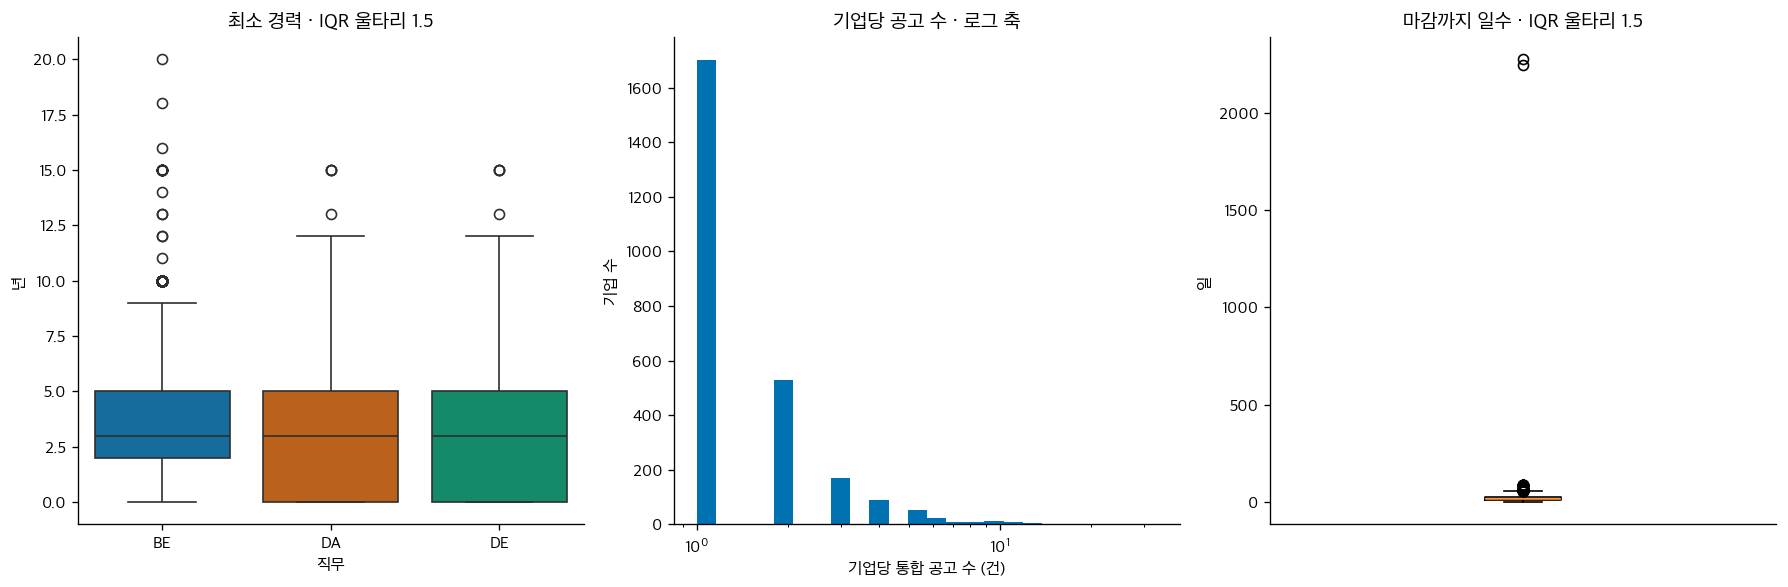

✍️ 변수별 IQR 규칙은 총 1,437개 관측값을 표시했다(동일 공고의 변수 중복 포함). IQR=0인 희소 키워드·신규 수에서는 양수가 모두 이상치가 될 수 있어 오류 판정으로 쓰지 않는다. 상시 마감의 NULL과 2070 센티널은 실제 마감까지 일수로 계산하지 않는다. Kruskal-Wallis 결과 {'H': np.float64(51.456721244684324), 'p': np.float64(6.703705904696832e-12), 'n': [2371, 297, 399]}도 탐색적이며 직무 분류·결측의 차이를 함께 고려해야 한다.

In [20]:
stats9=eda.stats_q9(snapshot)
display(stats9[0].round(3))
display(Markdown(eda.chart_q9(snapshot,stats9)))

<a id="eda-results"></a>

### EDA 결과와 재실행

[전체 공고 웹 화면](web/index.html) · [평가표·개선 계획](docs/NOTION-RUBRIC.md)

집계 표·그림·해석은 위 실행 출력에 보존했다. 통합·원천 공고, 상관 통계와 IQR 경계의 CSV는
재실행하면 `reports/`에 생성된다. 수집 종료 후 자동 마무리 과정에서 분리본과 통합본, 웹 자료를 갱신한다.
실제 종료 상태는 [finalization.json](reports/finalization.json)에서 확인한다.

이 자료는 하루의 부분 관측·플랫폼 직무 코드의 범위 차이·상세 수집 한도·현재 목록에 남은 공고의
편향을 포함한다. 기업별 공고 수는 고용 인원이 아니며 중복 통합과 키워드 검출은 추정이다.

In [21]:
with store.connect() as conn:
    final_slot=conn.execute("SELECT status FROM crawl_run WHERE run_kind='scheduled' AND slot_ts=timestamptz '2026-10-02 20:00+09'").fetchone()
finished=bool(final_slot and final_slot[0] in ('success','partial'))
checks={'SQL/pandas 교차 검증':all(v is True for v in validation.values() if isinstance(v,bool)),
        '원천 링크 누락 0':catalog_evidence['source_links']==len(snapshot['postings']),
        '필수 값 누락 0':int(snapshot['validity'].required_missing.sum())==0,
        '2070 센티널 잔존 0':int(snapshot['validity'].sentinel_leaks.sum())==0}
assert all(checks.values()),checks
display(pd.DataFrame(checks.items(),columns=['검증','통과']))
display(Markdown('**'+('최종 수집 자료' if finished else '부분 수집 자료 · 20:00 최종 실행 대기')+'** · 기준 슬롯 '+snapshot['asof']))
report={'asof':snapshot['asof'],'final_slot':finished,'validation':validation,'catalog':catalog_evidence,'checks':checks}
Path('reports/analysis_validation.json').write_text(json.dumps(report,ensure_ascii=False,indent=2))

,검증,통과
0,SQL/pandas 교차 검증,True
1,원천 링크 누락 0,True
2,필수 값 누락 0,True
3,2070 센티널 잔존 0,True


**부분 수집 자료 · 20:00 최종 실행 대기** · 기준 슬롯 2026-10-02 16:20:00+09:00

497

<a id="integrated-results"></a>

## 전체 실행 요약

원본 코드 21셀을 ETL → EDA 순서로 한 새 커널에서 실행했다. 실행 번호는 1–21이며 오류 출력은 0개다. PNG 그림 13개와 해석 출력 16개를 코드와 함께 보존했다.

이 요약은 실행기가 완료된 노트북을 검사한 결과다. [실행 기록](reports/integrated_notebook_validation.json)과 [평가표·개선 계획](docs/NOTION-RUBRIC.md)에서 근거를 확인할 수 있다. 원본 ETL·EDA의 코드 셀은 수정하지 않았으며, 통합본의 결과는 이번 실행의 DB 자료를 반영한다.